In [27]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import warnings

from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------

THESIS_DIR = Path(
    "/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS"
)

OUTPUT_ROOT = (
    THESIS_DIR
    / "outputs"
    / "chapter4"
)

THIRD_PARTY_DIR = (
    THESIS_DIR
    / "third_party"
    / "dl_fault_repo"
)

POSTHOC_DIR = (
    OUTPUT_ROOT
    / "posthoc_final"
)

ABLATION_DIR = (
    OUTPUT_ROOT
    / "ablation_final"
)

AUDIT_DIR = ABLATION_DIR / "audit"
TABLE_DIR = ABLATION_DIR / "tables"
FIGURE_DIR = ABLATION_DIR / "figures"
LATEX_DIR = ABLATION_DIR / "latex"

for directory in [
    ABLATION_DIR,
    AUDIT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    LATEX_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ---------------------------------------------------------------------
# Validated post-hoc inputs
# ---------------------------------------------------------------------

UNIFIED_EVENT_PATH = (
    POSTHOC_DIR
    / "posthoc_unified_event_predictions.parquet"
)

UNIFIED_WINDOW_PATH = (
    POSTHOC_DIR
    / "posthoc_unified_window_predictions.parquet"
)

PAIRED_PRIOR_PATH = (
    POSTHOC_DIR
    / "posthoc_paired_prior_comparison.csv"
)

EVENT_HEADLINE_PATH = (
    POSTHOC_DIR
    / "posthoc_event_headline_metrics.csv"
)

BOOTSTRAP_PATH = (
    POSTHOC_DIR
    / "posthoc_event_bootstrap_intervals.csv"
)

CORRECTION_VS_LEARNING_PATH = (
    POSTHOC_DIR
    / "posthoc_correction_vs_learning.csv"
)

EVENT_TAIL_PATH = (
    POSTHOC_DIR
    / "posthoc_event_tail_metrics.csv"
)

FOLD_SUMMARY_PATH = (
    POSTHOC_DIR
    / "posthoc_fold_summary.csv"
)

THESIS_SUBGROUP_SUMMARY_PATH = (
    POSTHOC_DIR
    / "posthoc_thesis_ready_subgroup_summary.csv"
)

WINDOW_HEADLINE_PATH = (
    POSTHOC_DIR
    / "posthoc_110kv_window_headline_metrics.csv"
)

WINDOW_CORRECTION_VS_LEARNING_PATH = (
    POSTHOC_DIR
    / "posthoc_110kv_correction_vs_learning_stability.csv"
)

INTEGRITY_PATH = (
    POSTHOC_DIR
    / "posthoc_integrity_audit.json"
)


# ---------------------------------------------------------------------
# Experiment order
# ---------------------------------------------------------------------

HYBRID_EXPERIMENT_ORDER = [
    "C90-1E",
    "L90-1E",
    "C110-1E",
    "L110-1E",
    "C90-2E",
    "L90-2E",
    "C110-2E",
    "L110-2E",
]

PHYSICS_EXPERIMENT_ORDER = [
    "P90-1E",
    "P90-2E",
    "P110-1E",
    "P110-2E",
]

ALL_FINAL_EXPERIMENTS = [
    "P90-1E",
    "P90-2E",
    "P110-1E",
    "P110-2E",
    "G90",
    "G110",
    *HYBRID_EXPERIMENT_ORDER,
]


# ---------------------------------------------------------------------
# Manual overrides
# ---------------------------------------------------------------------
#
# Leave values as None during the first run.
#
# If several GRU prediction files are equally plausible, paste the exact
# final file path here and rerun the GRU cells.
# ---------------------------------------------------------------------

GRU_SELECTION_OVERRIDES = {
    "G90": None,
    "G110": None,
}


# Optional manual physical-operator definitions.
#
# Add an entry only when automatic column discovery misses a known
# operator result.
#
# Example:
#
# PHYSICS_OPERATOR_OVERRIDES = [
#     {
#         "path": "/absolute/path/to/file.csv",
#         "voltage_kv": 110,
#         "prior_view": "1E",
#         "target_column": "y_fault_location",
#         "sample_id_column": "sample_id",
#         "window_column": "window_idx",
#         "operator_columns": [
#             "d_old_pct",
#             "d_takagi_local_pct",
#             "d_takagi_remote_flipped_pct",
#             "d_selected_pct",
#         ],
#     }
# ]
# ---------------------------------------------------------------------

PHYSICS_OPERATOR_OVERRIDES: list[dict[str, Any]] = []


# ---------------------------------------------------------------------
# Numerical settings
# ---------------------------------------------------------------------
TARGET_ALIGNMENT_TOLERANCE_PP = 1e-5
NUMERIC_TOLERANCE = 1e-8
CSV_LINE_COUNT_LIMIT_BYTES = 500 * 1024 * 1024


print("Post-hoc directory:", POSTHOC_DIR)
print("Ablation output:", ABLATION_DIR)
print("Figures:", FIGURE_DIR)

Post-hoc directory: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/posthoc_final
Ablation output: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final
Figures: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final/figures


In [2]:
def normalize_column_name(
    value: str,
) -> str:
    value = str(value).strip().lower()

    value = re.sub(
        r"[^a-z0-9]+",
        "_",
        value,
    )

    return value.strip("_")


def normalized_column_lookup(
    frame: pd.DataFrame,
) -> dict[str, str]:
    return {
        normalize_column_name(column): column
        for column in frame.columns
    }


def find_column(
    frame: pd.DataFrame,
    candidates: Iterable[str],
    *,
    required: bool = False,
) -> str | None:
    lookup = normalized_column_lookup(frame)

    for candidate in candidates:
        normalized = normalize_column_name(
            candidate
        )

        if normalized in lookup:
            return lookup[normalized]

    if required:
        raise KeyError(
            "None of the required columns were found: "
            f"{list(candidates)}\n"
            f"Available columns: {list(frame.columns)}"
        )

    return None


def read_table(
    path: Path,
) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix in {
        ".parquet",
        ".pq",
    }:
        return pd.read_parquet(path)

    if suffix in {
        ".json",
        ".jsonl",
    }:
        return pd.read_json(
            path,
            lines=suffix == ".jsonl",
        )

    raise ValueError(
        f"Unsupported table format: {path}"
    )


def finite_numeric(
    values: pd.Series,
) -> np.ndarray:
    numeric = pd.to_numeric(
        values,
        errors="coerce",
    ).to_numpy(dtype=float)

    return numeric[
        np.isfinite(numeric)
    ]


def cvar_upper(
    values: np.ndarray,
    quantile: float = 0.95,
) -> float:
    numeric = np.asarray(
        values,
        dtype=float,
    )

    numeric = numeric[
        np.isfinite(numeric)
    ]

    if len(numeric) == 0:
        return np.nan

    threshold = np.quantile(
        numeric,
        quantile,
    )

    return float(
        numeric[
            numeric >= threshold
        ].mean()
    )


def summarize_errors(
    errors: pd.Series | np.ndarray,
) -> dict[str, float]:
    values = np.asarray(
        errors,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return {
            "mae_pp": np.nan,
            "rmse_pp": np.nan,
            "median_ae_pp": np.nan,
            "p90_ae_pp": np.nan,
            "p95_ae_pp": np.nan,
            "p99_ae_pp": np.nan,
            "cvar95_pp": np.nan,
            "exceed_10pp_rate_pct": np.nan,
        }

    return {
        "mae_pp": float(
            np.mean(values)
        ),
        "rmse_pp": float(
            np.sqrt(
                np.mean(
                    np.square(values)
                )
            )
        ),
        "median_ae_pp": float(
            np.median(values)
        ),
        "p90_ae_pp": float(
            np.quantile(
                values,
                0.90,
            )
        ),
        "p95_ae_pp": float(
            np.quantile(
                values,
                0.95,
            )
        ),
        "p99_ae_pp": float(
            np.quantile(
                values,
                0.99,
            )
        ),
        "cvar95_pp": cvar_upper(
            values,
            0.95,
        ),
        "exceed_10pp_rate_pct": float(
            100.0
            * np.mean(
                values > 10.0
            )
        ),
    }


def maybe_scale_to_percent(
    values: pd.Series,
    *,
    reference: pd.Series | None = None,
) -> tuple[pd.Series, str]:
    numeric = pd.to_numeric(
        values,
        errors="coerce",
    )

    finite = numeric[
        np.isfinite(numeric)
    ]

    if finite.empty:
        return numeric, "unknown"

    if reference is not None:
        reference_numeric = pd.to_numeric(
            reference,
            errors="coerce",
        )

        reference_finite = reference_numeric[
            np.isfinite(reference_numeric)
        ]

        if not reference_finite.empty:
            reference_max = float(
                reference_finite.abs().quantile(
                    0.99
                )
            )

            value_max = float(
                finite.abs().quantile(
                    0.99
                )
            )

            if (
                reference_max <= 1.5
                and value_max <= 1.5
            ):
                return (
                    numeric * 100.0,
                    "scaled_fraction_to_percent",
                )

            if (
                reference_max > 1.5
                and value_max <= 1.5
            ):
                return (
                    numeric * 100.0,
                    "prediction_scaled_to_percent",
                )

            return numeric, "already_percent"

    value_max = float(
        finite.abs().quantile(
            0.99
        )
    )

    if value_max <= 1.5:
        return (
            numeric * 100.0,
            "scaled_fraction_to_percent",
        )

    return numeric, "already_percent"


def write_latex_table(
    frame: pd.DataFrame,
    path: Path,
    *,
    float_format: str = "%.3f",
) -> None:
    latex = frame.to_latex(
        index=False,
        escape=True,
        na_rep="--",
        float_format=float_format,
    )

    path.write_text(
        latex,
        encoding="utf-8",
    )


def stable_identifier_hash(
    values: pd.Series,
) -> str:
    ordered = (
        values
        .astype(str)
        .sort_values()
        .tolist()
    )

    payload = "\n".join(
        ordered
    ).encode("utf-8")

    return hashlib.sha256(
        payload
    ).hexdigest()[:16]


def parse_experiment_id(
    experiment_id: str,
) -> dict[str, Any]:
    match = re.fullmatch(
        r"([CL])(\d+)-(1E|2E)",
        str(experiment_id),
    )

    if match is None:
        raise ValueError(
            f"Unrecognized hybrid experiment: "
            f"{experiment_id}"
        )

    family_code, voltage, prior_view = (
        match.groups()
    )

    return {
        "voltage_kv": int(voltage),
        "prior_view": prior_view,
        "model_family": (
            "correction"
            if family_code == "C"
            else "bounded_learning"
        ),
    }


def infer_voltage_from_text(
    value: str,
) -> int | None:
    text = str(value).lower()

    if re.search(
        r"(^|[^0-9])110\s*k?v([^0-9]|$)",
        text,
    ):
        return 110

    if re.search(
        r"(^|[^0-9])90\s*k?v([^0-9]|$)",
        text,
    ):
        return 90

    if "110kv" in text:
        return 110

    if "90kv" in text:
        return 90

    return None


def infer_prior_view_from_text(
    value: str,
) -> str | None:
    text = str(value).lower()

    two_ended_patterns = [
        "2e",
        "two_ended",
        "two-ended",
        "double_ended",
        "double-ended",
        "doubleended",
        "synchronized",
        "posseq",
        "positive_sequence",
        "positive-sequence",
    ]

    one_ended_patterns = [
        "1e",
        "one_ended",
        "one-ended",
        "oneended",
        "single_ended",
        "single-ended",
        "singleended",
        "takagi_local",
        "takagi_remote",
    ]

    if any(
        pattern in text
        for pattern in two_ended_patterns
    ):
        return "2E"

    if any(
        pattern in text
        for pattern in one_ended_patterns
    ):
        return "1E"

    return None


def classify_operator_stage(
    operator_name: str,
) -> str:
    text = normalize_column_name(
        operator_name
    )

    if any(
        key in text
        for key in [
            "two_ended",
            "double_ended",
            "posseq",
            "positive_sequence",
            "synchronized",
        ]
    ):
        return "synchronized_two_ended"

    if (
        "selected" in text
        or "case_aware" in text
        or "caseaware" in text
    ):
        return "case_aware_selection"

    if (
        "remote_flipped" in text
        or "direction_corrected" in text
        or "remote_flip" in text
    ):
        return "remote_direction_corrected"

    if (
        "both_mean" in text
        or "local_remote_mean" in text
        or "mean_local_remote" in text
    ):
        return "local_remote_mean"

    if "modified_takagi" in text:
        return "modified_takagi"

    if (
        "takagi_remote" in text
        or (
            "takagi" in text
            and "remote" in text
        )
    ):
        return "takagi_remote"

    if (
        "takagi_local" in text
        or (
            "takagi" in text
            and "local" in text
        )
    ):
        return "takagi_local"

    if "takagi" in text:
        return "takagi"

    if any(
        key in text
        for key in [
            "old",
            "impedance",
            "original",
            "baseline",
        ]
    ):
        return "initial_impedance"

    return "unclassified_operator"


OPERATOR_STAGE_ORDER = {
    "initial_impedance": 0,
    "takagi": 1,
    "takagi_local": 2,
    "takagi_remote": 3,
    "remote_direction_corrected": 4,
    "local_remote_mean": 5,
    "case_aware_selection": 6,
    "modified_takagi": 7,
    "synchronized_two_ended": 8,
    "unclassified_operator": 99,
}

In [3]:
required_paths = [
    INTEGRITY_PATH,
    UNIFIED_EVENT_PATH,
    UNIFIED_WINDOW_PATH,
    PAIRED_PRIOR_PATH,
    EVENT_HEADLINE_PATH,
    BOOTSTRAP_PATH,
    EVENT_TAIL_PATH,
    FOLD_SUMMARY_PATH,
    THESIS_SUBGROUP_SUMMARY_PATH,
    WINDOW_HEADLINE_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Required validated post-hoc outputs are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )


with INTEGRITY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    integrity_payload = json.load(file)


if integrity_payload.get(
    "overall_status"
) != "PASS":
    raise RuntimeError(
        "The mandatory post-hoc integrity audit "
        "did not pass."
    )


unified_event = pd.read_parquet(
    UNIFIED_EVENT_PATH
)

unified_window = pd.read_parquet(
    UNIFIED_WINDOW_PATH
)

paired_prior_raw = pd.read_csv(
    PAIRED_PRIOR_PATH
)

event_headline_raw = pd.read_csv(
    EVENT_HEADLINE_PATH
)

bootstrap_raw = pd.read_csv(
    BOOTSTRAP_PATH
)

event_tail_raw = pd.read_csv(
    EVENT_TAIL_PATH
)

fold_summary_raw = pd.read_csv(
    FOLD_SUMMARY_PATH
)

thesis_subgroup_raw = pd.read_csv(
    THESIS_SUBGROUP_SUMMARY_PATH
)

window_headline_raw = pd.read_csv(
    WINDOW_HEADLINE_PATH
)

if CORRECTION_VS_LEARNING_PATH.exists():
    correction_vs_learning_raw = pd.read_csv(
        CORRECTION_VS_LEARNING_PATH
    )
else:
    correction_vs_learning_raw = pd.DataFrame()

if (
    WINDOW_CORRECTION_VS_LEARNING_PATH
    .exists()
):
    window_correction_vs_learning_raw = (
        pd.read_csv(
            WINDOW_CORRECTION_VS_LEARNING_PATH
        )
    )
else:
    window_correction_vs_learning_raw = (
        pd.DataFrame()
    )


observed_experiments = set(
    unified_event["experiment_id"]
    .astype(str)
    .unique()
)

expected_experiments = set(
    HYBRID_EXPERIMENT_ORDER
)

if observed_experiments != expected_experiments:
    raise RuntimeError(
        "Unexpected unified event experiment set.\n"
        f"Expected: {sorted(expected_experiments)}\n"
        f"Observed: {sorted(observed_experiments)}"
    )


print("Integrity status: PASS")
print(
    "Unified event rows:",
    f"{len(unified_event):,}",
)
print(
    "Unified window rows:",
    f"{len(unified_window):,}",
)

display(
    unified_event[
        "experiment_id"
    ].value_counts().reindex(
        HYBRID_EXPERIMENT_ORDER
    ).rename(
        "event_rows"
    ).to_frame()
)

Integrity status: PASS
Unified event rows: 39,736
Unified window rows: 50,680


,event_rows
experiment_id,
C90-1E,9022
L90-1E,9022
C110-1E,912
L110-1E,912
C90-2E,9022
L90-2E,9022
C110-2E,912
L110-2E,912


In [5]:
METRIC_COLUMN_ALIASES = {
    "experiment_id": [
        "experiment_id",
        "experiment",
        "model_id",
    ],

    "n_events": [
        "n_events",
        "event_count",
        "support",
        "events",
    ],

    "prior_mae_pp": [
        "prior_mae_pp",
        "baseline_mae_pp",
    ],

    "model_mae_pp": [
        "model_mae_pp",
        "event_model_mae_pp",
        "mae_pp",
    ],

    "mae_reduction_pp": [
        "mae_reduction_pp",
        "mean_gain_pp",
        "absolute_mae_reduction_pp",
    ],

    "relative_mae_reduction_pct": [
        "relative_mae_reduction_pct",
        "relative_reduction_pct",
        "mae_reduction_pct",
    ],

    "improved_event_rate_pct": [
        "improved_event_rate_pct",
        "improved_rate_pct",
        "event_improved_rate_pct",
    ],

    "worsened_event_rate_pct": [
        "worsened_event_rate_pct",
        "worsened_rate_pct",
        "event_worsened_rate_pct",
    ],

    "bootstrap_ci_lower_pp": [
        "bootstrap_ci_lower_pp",
        "ci95_lower_pp",
        "ci_lower_pp",
        "mean_gain_ci_lower_pp",
        "lower_95_pp",
        "bootstrap_lower_pp",
    ],

    "bootstrap_ci_upper_pp": [
        "bootstrap_ci_upper_pp",
        "ci95_upper_pp",
        "ci_upper_pp",
        "mean_gain_ci_upper_pp",
        "upper_95_pp",
        "bootstrap_upper_pp",
    ],

    "model_rmse_pp": [
        "model_rmse_pp",
        "rmse_pp",
    ],

    "model_median_ae_pp": [
        "model_median_ae_pp",
        "median_ae_pp",
        "median_absolute_error_pp",
    ],

    "model_p90_ae_pp": [
        "model_p90_ae_pp",
        "p90_ae_pp",
        "p90_pp",
    ],

    "model_p95_ae_pp": [
        "model_p95_ae_pp",
        "p95_ae_pp",
        "p95_pp",
    ],

    "model_p99_ae_pp": [
        "model_p99_ae_pp",
        "p99_ae_pp",
        "p99_pp",
    ],

    "model_cvar95_pp": [
        "model_cvar95_pp",
        "cvar95_pp",
    ],

    "model_exceed_10pp_rate_pct": [
        "model_exceed_10pp_rate_pct",
        "exceed_10pp_rate_pct",
        "error_above_10pp_rate_pct",
    ],

    "worst_fold_model_mae_pp": [
        "worst_fold_model_mae_pp",
        "worst_fold_mae_pp",
    ],

    "fold_model_mae_std_pp": [
        "fold_model_mae_std_pp",
        "fold_mae_std_pp",
    ],

    "folds_with_positive_gain": [
        "folds_with_positive_gain",
        "positive_gain_folds",
    ],

    "folds_with_negative_gain": [
        "folds_with_negative_gain",
        "negative_gain_folds",
    ],
}


def standardize_metric_table(
    frame: pd.DataFrame,
    source_name: str,
) -> pd.DataFrame:
    standardized = pd.DataFrame()

    experiment_column = find_column(
        frame,
        METRIC_COLUMN_ALIASES[
            "experiment_id"
        ],
        required=True,
    )

    standardized["experiment_id"] = (
        frame[experiment_column]
        .astype(str)
    )

    for canonical_name, aliases in (
        METRIC_COLUMN_ALIASES.items()
    ):
        if canonical_name == "experiment_id":
            continue

        source_column = find_column(
            frame,
            aliases,
            required=False,
        )

        if source_column is not None:
            standardized[
                canonical_name
            ] = frame[source_column]

    standardized["_source"] = source_name

    standardized = standardized.loc[
        standardized["experiment_id"].isin(
            HYBRID_EXPERIMENT_ORDER
        )
    ].copy()

    return standardized


metric_sources = {
    "paired_prior": paired_prior_raw,
    "event_headline": event_headline_raw,
    "bootstrap": bootstrap_raw,
    "event_tail": event_tail_raw,
    "fold_summary": fold_summary_raw,
    "thesis_subgroup": thesis_subgroup_raw,
}


standardized_sources = {
    source_name: standardize_metric_table(
        source_frame,
        source_name,
    )
    for source_name, source_frame
    in metric_sources.items()
}


hybrid_metrics = pd.DataFrame(
    {
        "experiment_id": (
            HYBRID_EXPERIMENT_ORDER
        )
    }
)

metric_conflicts = []


for source_name, standardized in (
    standardized_sources.items()
):
    standardized = (
        standardized
        .drop(columns="_source")
        .drop_duplicates(
            subset="experiment_id",
            keep="first",
        )
    )

    for column in standardized.columns:
        if column == "experiment_id":
            continue

        source_values = standardized[
            [
                "experiment_id",
                column,
            ]
        ].rename(
            columns={
                column: (
                    f"{column}__{source_name}"
                )
            }
        )

        hybrid_metrics = hybrid_metrics.merge(
            source_values,
            on="experiment_id",
            how="left",
            validate="one_to_one",
        )


for canonical_name in (
    set(METRIC_COLUMN_ALIASES)
    - {"experiment_id"}
):
    candidate_columns = [
        column
        for column in hybrid_metrics.columns
        if column.startswith(
            f"{canonical_name}__"
        )
    ]

    if not candidate_columns:
        continue

    combined = pd.Series(
        np.nan,
        index=hybrid_metrics.index,
        dtype=object,
    )

    for candidate_column in candidate_columns:
        candidate_values = hybrid_metrics[
            candidate_column
        ]

        overlap = (
            combined.notna()
            & candidate_values.notna()
        )

        if overlap.any():
            left_numeric = pd.to_numeric(
                combined[overlap],
                errors="coerce",
            )

            right_numeric = pd.to_numeric(
                candidate_values[overlap],
                errors="coerce",
            )

            numeric_overlap = (
                left_numeric.notna()
                & right_numeric.notna()
            )

            if numeric_overlap.any():
                maximum_difference = float(
                    (
                        left_numeric[
                            numeric_overlap
                        ]
                        - right_numeric[
                            numeric_overlap
                        ]
                    )
                    .abs()
                    .max()
                )

                if maximum_difference > 1e-5:
                    metric_conflicts.append(
                        {
                            "metric": canonical_name,
                            "source_column": (
                                candidate_column
                            ),
                            "max_difference": (
                                maximum_difference
                            ),
                        }
                    )

        combined = combined.combine_first(
            candidate_values
        )

    hybrid_metrics[
        canonical_name
    ] = combined


source_columns = [
    column
    for column in hybrid_metrics.columns
    if "__" in column
]

hybrid_metrics = hybrid_metrics.drop(
    columns=source_columns
)


for experiment_id in (
    HYBRID_EXPERIMENT_ORDER
):
    parsed = parse_experiment_id(
        experiment_id
    )

    mask = (
        hybrid_metrics["experiment_id"]
        == experiment_id
    )

    for key, value in parsed.items():
        hybrid_metrics.loc[
            mask,
            key,
        ] = value


hybrid_metrics["voltage_kv"] = (
    hybrid_metrics["voltage_kv"]
    .astype(int)
)


print("Metric conflicts requiring review:")
display(pd.DataFrame(metric_conflicts))

display(hybrid_metrics)

Metric conflicts requiring review:


/tmp/ipykernel_1958518/1682796769.py:319: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combined = combined.combine_first(
/tmp/ipykernel_1958518/1682796769.py:319: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combined = combined.combine_first(
/tmp/ipykernel_1958518/1682796769.py:319: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combin

""


,experiment_id,bootstrap_ci_lower_pp,model_median_ae_pp,fold_model_mae_std_pp,worsened_event_rate_pct,model_rmse_pp,model_mae_pp,relative_mae_reduction_pct,model_exceed_10pp_rate_pct,prior_mae_pp,...,folds_with_positive_gain,model_p95_ae_pp,model_cvar95_pp,worst_fold_model_mae_pp,model_p99_ae_pp,n_events,model_p90_ae_pp,voltage_kv,prior_view,model_family
0,C90-1E,0.938860,3.560103,0.223614,30.203946,10.841297,6.265098,14.436127,17.335402,7.322130,...,5,20.365432,35.836683,6.652824,45.407452,9022,13.964525,90,1E,correction
1,L90-1E,0.948886,3.426525,0.209167,28.962536,11.294902,6.288006,14.123271,16.725781,7.322130,...,5,20.756001,38.544771,6.658091,50.703904,9022,13.507031,90,1E,bounded_learning
2,C110-1E,4.208828,2.734740,0.821716,22.697368,12.327856,6.636678,43.239611,20.833333,11.692447,...,5,20.000000,33.758650,7.334237,50.000000,912,19.227699,110,1E,correction
3,L110-1E,3.162477,4.140876,0.987993,23.026316,13.009082,7.825728,33.070232,28.179825,11.692447,...,5,23.487724,40.539749,9.422429,50.000000,912,19.999999,110,1E,bounded_learning
4,C90-2E,-0.215734,0.387574,0.246740,65.850144,5.798404,1.347025,-17.273892,2.105963,1.148614,...,0,3.024826,16.396556,1.827926,26.944893,9022,1.770787,90,2E,correction
5,L90-2E,-0.007002,0.168535,0.155119,51.928619,5.824848,1.153115,-0.391818,2.128131,1.148614,...,0,2.687269,16.558445,1.432406,27.296386,9022,1.379534,90,2E,bounded_learning
6,C110-2E,-0.249709,0.296863,0.077895,67.763158,0.673991,0.468317,-87.983652,0.000000,0.249126,...,0,1.466556,1.930941,0.572769,2.213075,912,1.109753,110,2E,correction
7,L110-2E,0.002226,0.167609,0.020035,52.412281,0.350200,0.238907,4.102232,0.000000,0.249126,...,4,0.683732,1.030423,0.270288,1.251428,912,0.527329,110,2E,bounded_learning


In [6]:
required_event_columns = [
    "experiment_id",
    "sample_id",
    "fold",
    "y_true_pct",
    "y_prior_pct",
    "y_pred_pct",
]

missing_event_columns = [
    column
    for column in required_event_columns
    if column not in unified_event.columns
]

if missing_event_columns:
    raise KeyError(
        "Unified event table is missing columns: "
        f"{missing_event_columns}"
    )


event_metric_rows = []


for experiment_id, frame in (
    unified_event.groupby(
        "experiment_id",
        sort=False,
    )
):
    model_error = (
        pd.to_numeric(
            frame["y_pred_pct"],
            errors="coerce",
        )
        - pd.to_numeric(
            frame["y_true_pct"],
            errors="coerce",
        )
    ).abs()

    prior_error = (
        pd.to_numeric(
            frame["y_prior_pct"],
            errors="coerce",
        )
        - pd.to_numeric(
            frame["y_true_pct"],
            errors="coerce",
        )
    ).abs()

    model_summary = summarize_errors(
        model_error
    )

    prior_summary = summarize_errors(
        prior_error
    )

    gain = prior_error - model_error

    event_metric_rows.append(
        {
            "experiment_id": experiment_id,
            "n_events_verified": int(
                len(frame)
            ),

            "prior_mae_pp_verified": (
                prior_summary["mae_pp"]
            ),

            "model_mae_pp_verified": (
                model_summary["mae_pp"]
            ),

            "mae_reduction_pp_verified": float(
                gain.mean()
            ),

            "relative_mae_reduction_pct_verified": float(
                100.0
                * gain.mean()
                / prior_summary["mae_pp"]
            ),

            "improved_event_rate_pct_verified": float(
                100.0
                * np.mean(
                    gain
                    > NUMERIC_TOLERANCE
                )
            ),

            "worsened_event_rate_pct_verified": float(
                100.0
                * np.mean(
                    gain
                    < -NUMERIC_TOLERANCE
                )
            ),

            "model_rmse_pp_verified": (
                model_summary["rmse_pp"]
            ),

            "model_median_ae_pp_verified": (
                model_summary[
                    "median_ae_pp"
                ]
            ),

            "model_p90_ae_pp_verified": (
                model_summary["p90_ae_pp"]
            ),

            "model_p95_ae_pp_verified": (
                model_summary["p95_ae_pp"]
            ),

            "model_p99_ae_pp_verified": (
                model_summary["p99_ae_pp"]
            ),

            "model_cvar95_pp_verified": (
                model_summary["cvar95_pp"]
            ),

            "model_exceed_10pp_rate_pct_verified": (
                model_summary[
                    "exceed_10pp_rate_pct"
                ]
            ),
        }
    )


verified_event_metrics = pd.DataFrame(
    event_metric_rows
)


hybrid_metrics = hybrid_metrics.merge(
    verified_event_metrics,
    on="experiment_id",
    how="left",
    validate="one_to_one",
)


verification_pairs = [
    (
        "prior_mae_pp",
        "prior_mae_pp_verified",
    ),
    (
        "model_mae_pp",
        "model_mae_pp_verified",
    ),
    (
        "mae_reduction_pp",
        "mae_reduction_pp_verified",
    ),
]


verification_rows = []


for original_column, verified_column in (
    verification_pairs
):
    if original_column not in hybrid_metrics:
        hybrid_metrics[
            original_column
        ] = hybrid_metrics[
            verified_column
        ]

    difference = (
        pd.to_numeric(
            hybrid_metrics[
                original_column
            ],
            errors="coerce",
        )
        - pd.to_numeric(
            hybrid_metrics[
                verified_column
            ],
            errors="coerce",
        )
    ).abs()

    verification_rows.append(
        {
            "metric": original_column,
            "max_difference": float(
                difference.max()
            ),
            "verified": bool(
                difference.max()
                <= 1e-5
            ),
        }
    )


for target_column, verified_column in [
    (
        "relative_mae_reduction_pct",
        "relative_mae_reduction_pct_verified",
    ),
    (
        "improved_event_rate_pct",
        "improved_event_rate_pct_verified",
    ),
    (
        "worsened_event_rate_pct",
        "worsened_event_rate_pct_verified",
    ),
    (
        "model_rmse_pp",
        "model_rmse_pp_verified",
    ),
    (
        "model_median_ae_pp",
        "model_median_ae_pp_verified",
    ),
    (
        "model_p90_ae_pp",
        "model_p90_ae_pp_verified",
    ),
    (
        "model_p95_ae_pp",
        "model_p95_ae_pp_verified",
    ),
    (
        "model_p99_ae_pp",
        "model_p99_ae_pp_verified",
    ),
    (
        "model_cvar95_pp",
        "model_cvar95_pp_verified",
    ),
    (
        "model_exceed_10pp_rate_pct",
        "model_exceed_10pp_rate_pct_verified",
    ),
]:
    if target_column not in hybrid_metrics:
        hybrid_metrics[
            target_column
        ] = hybrid_metrics[
            verified_column
        ]
    else:
        hybrid_metrics[
            target_column
        ] = hybrid_metrics[
            target_column
        ].combine_first(
            hybrid_metrics[
                verified_column
            ]
        )


display(
    pd.DataFrame(
        verification_rows
    )
)


if not all(
    row["verified"]
    for row in verification_rows
):
    raise RuntimeError(
        "Validated post-hoc metrics do not match "
        "the unified OOF event table."
    )


hybrid_metrics.to_csv(
    AUDIT_DIR
    / "validated_hybrid_metric_registry.csv",
    index=False,
)


display(
    hybrid_metrics[
        [
            "experiment_id",
            "voltage_kv",
            "prior_view",
            "model_family",
            "prior_mae_pp",
            "model_mae_pp",
            "mae_reduction_pp",
            "relative_mae_reduction_pct",
            "model_rmse_pp",
            "model_p95_ae_pp",
            "model_cvar95_pp",
        ]
    ]
)

,metric,max_difference,verified
0,prior_mae_pp,8.326673e-17,True
1,model_mae_pp,8.326673e-17,True
2,mae_reduction_pp,8.881784e-16,True


,experiment_id,voltage_kv,prior_view,model_family,prior_mae_pp,model_mae_pp,mae_reduction_pp,relative_mae_reduction_pct,model_rmse_pp,model_p95_ae_pp,model_cvar95_pp
0,C90-1E,90,1E,correction,7.322130,6.265098,1.057032,14.436127,10.841297,20.365432,35.836683
1,L90-1E,90,1E,bounded_learning,7.322130,6.288006,1.034124,14.123271,11.294902,20.756001,38.544771
2,C110-1E,110,1E,correction,11.692447,6.636678,5.055769,43.239611,12.327856,20.000000,33.758650
3,L110-1E,110,1E,bounded_learning,11.692447,7.825728,3.866719,33.070232,13.009082,23.487724,40.539749
4,C90-2E,90,2E,correction,1.148614,1.347025,-0.198410,-17.273892,5.798404,3.024826,16.396556
5,L90-2E,90,2E,bounded_learning,1.148614,1.153115,-0.004500,-0.391818,5.824848,2.687269,16.558445
6,C110-2E,110,2E,correction,0.249126,0.468317,-0.219191,-87.983652,0.673991,1.466556,1.930941
7,L110-2E,110,2E,bounded_learning,0.249126,0.238907,0.010220,4.102232,0.350200,0.683732,1.030423


In [7]:
prior_reference_frames = []
prior_alignment_rows = []


for voltage_kv in [
    90,
    110,
]:
    for prior_view in [
        "1E",
        "2E",
    ]:
        correction_id = (
            f"C{voltage_kv}-{prior_view}"
        )

        learning_id = (
            f"L{voltage_kv}-{prior_view}"
        )

        correction = unified_event.loc[
            unified_event["experiment_id"]
            == correction_id
        ].copy()

        learning = unified_event.loc[
            unified_event["experiment_id"]
            == learning_id
        ].copy()

        merged = correction[
            [
                "sample_id",
                "fold",
                "y_true_pct",
                "y_prior_pct",
            ]
        ].merge(
            learning[
                [
                    "sample_id",
                    "fold",
                    "y_true_pct",
                    "y_prior_pct",
                ]
            ],
            on="sample_id",
            how="inner",
            validate="one_to_one",
            suffixes=(
                "_correction",
                "_learning",
            ),
        )

        same_event_count = bool(
            len(merged)
            == len(correction)
            == len(learning)
        )

        target_difference = float(
            (
                merged[
                    "y_true_pct_correction"
                ]
                - merged[
                    "y_true_pct_learning"
                ]
            )
            .abs()
            .max()
        )

        prior_difference = float(
            (
                merged[
                    "y_prior_pct_correction"
                ]
                - merged[
                    "y_prior_pct_learning"
                ]
            )
            .abs()
            .max()
        )

        fold_match = bool(
            (
                merged[
                    "fold_correction"
                ].astype(str)
                == merged[
                    "fold_learning"
                ].astype(str)
            ).all()
        )

        alignment_ok = bool(
            same_event_count
            and target_difference
            <= NUMERIC_TOLERANCE
            and prior_difference
            <= NUMERIC_TOLERANCE
            and fold_match
        )

        prior_alignment_rows.append(
            {
                "voltage_kv": voltage_kv,
                "prior_view": prior_view,
                "correction_experiment": (
                    correction_id
                ),
                "learning_experiment": (
                    learning_id
                ),
                "event_count": len(merged),
                "target_max_difference": (
                    target_difference
                ),
                "prior_max_difference": (
                    prior_difference
                ),
                "fold_match": fold_match,
                "alignment_ok": alignment_ok,
            }
        )

        if not alignment_ok:
            raise RuntimeError(
                "Correction and bounded-learning "
                "priors are not aligned for "
                f"{voltage_kv} kV {prior_view}."
            )

        reference = correction[
            [
                "sample_id",
                "fold",
                "y_true_pct",
                "y_prior_pct",
            ]
        ].copy()

        reference["experiment_id"] = (
            f"P{voltage_kv}-{prior_view}"
        )

        reference["voltage_kv"] = (
            voltage_kv
        )

        reference["prior_view"] = (
            prior_view
        )

        reference = reference.rename(
            columns={
                "y_prior_pct": "y_pred_pct",
            }
        )

        prior_reference_frames.append(
            reference
        )


prior_alignment = pd.DataFrame(
    prior_alignment_rows
)

prior_event_reference = pd.concat(
    prior_reference_frames,
    ignore_index=True,
)


prior_summary_rows = []


for experiment_id, frame in (
    prior_event_reference.groupby(
        "experiment_id",
        sort=False,
    )
):
    error = (
        frame["y_pred_pct"]
        - frame["y_true_pct"]
    ).abs()

    summary = summarize_errors(
        error
    )

    prior_summary_rows.append(
        {
            "experiment_id": experiment_id,
            "voltage_kv": int(
                frame["voltage_kv"].iloc[0]
            ),
            "prior_view": frame[
                "prior_view"
            ].iloc[0],
            "model_family": (
                "physics_prior"
            ),
            "n_events": int(
                len(frame)
            ),
            **summary,
            "event_id_hash": (
                stable_identifier_hash(
                    frame["sample_id"]
                )
            ),
        }
    )


physics_prior_summary = pd.DataFrame(
    prior_summary_rows
)


prior_alignment.to_csv(
    AUDIT_DIR
    / "paired_prior_alignment.csv",
    index=False,
)

physics_prior_summary.to_csv(
    TABLE_DIR
    / "physics_prior_summary.csv",
    index=False,
)


display(prior_alignment)
display(physics_prior_summary)

,voltage_kv,prior_view,correction_experiment,learning_experiment,event_count,target_max_difference,prior_max_difference,fold_match,alignment_ok
0,90,1E,C90-1E,L90-1E,9022,0.0,0.0,True,True
1,90,2E,C90-2E,L90-2E,9022,0.0,0.0,True,True
2,110,1E,C110-1E,L110-1E,912,0.0,0.0,True,True
3,110,2E,C110-2E,L110-2E,912,0.0,0.0,True,True


,experiment_id,voltage_kv,prior_view,model_family,n_events,mae_pp,rmse_pp,median_ae_pp,p90_ae_pp,p95_ae_pp,p99_ae_pp,cvar95_pp,exceed_10pp_rate_pct,event_id_hash
0,P90-1E,90,1E,physics_prior,9022,7.322130,12.718774,4.179779,16.073068,24.222094,57.064466,42.810037,21.292396,290771d09d499d51
1,P90-2E,90,2E,physics_prior,9022,1.148614,5.829026,0.145044,1.404605,2.736914,27.330984,16.590048,2.128131,290771d09d499d51
2,P110-1E,110,1E,physics_prior,912,11.692447,19.257104,4.817352,31.182560,49.000001,51.046183,54.689673,35.745614,57217c1b3bbb44f6
3,P110-2E,110,2E,physics_prior,912,0.249126,0.371997,0.174663,0.577632,0.751048,1.328229,1.120845,0.000000,57217c1b3bbb44f6


In [8]:
prior_quality_columns = [
    "experiment_id",
    "voltage_kv",
    "prior_view",
    "model_family",
    "n_events_verified",
    "prior_mae_pp",
    "model_mae_pp",
    "mae_reduction_pp",
    "relative_mae_reduction_pct",
    "improved_event_rate_pct",
    "worsened_event_rate_pct",
    "bootstrap_ci_lower_pp",
    "bootstrap_ci_upper_pp",
    "folds_with_positive_gain",
    "folds_with_negative_gain",
]


for required_column in [
    "bootstrap_ci_lower_pp",
    "bootstrap_ci_upper_pp",
]:
    if required_column not in hybrid_metrics:
        warnings.warn(
            f"{required_column} was not found in "
            "the validated bootstrap output."
        )

        hybrid_metrics[
            required_column
        ] = np.nan


for required_column in [
    "folds_with_positive_gain",
    "folds_with_negative_gain",
]:
    if required_column not in hybrid_metrics:
        warnings.warn(
            f"{required_column} was not found in "
            "the validated fold output."
        )

        hybrid_metrics[
            required_column
        ] = np.nan


ablation_prior_quality = (
    hybrid_metrics[
        prior_quality_columns
    ]
    .copy()
)


experiment_order_map = {
    experiment_id: index
    for index, experiment_id
    in enumerate(
        HYBRID_EXPERIMENT_ORDER
    )
}

ablation_prior_quality[
    "_sort_order"
] = ablation_prior_quality[
    "experiment_id"
].map(
    experiment_order_map
)

ablation_prior_quality = (
    ablation_prior_quality
    .sort_values(
        "_sort_order",
        kind="stable",
    )
    .drop(columns="_sort_order")
    .reset_index(drop=True)
)


ablation_prior_quality.to_csv(
    TABLE_DIR
    / "ablation_prior_quality.csv",
    index=False,
)

write_latex_table(
    ablation_prior_quality,
    LATEX_DIR
    / "ablation_prior_quality.tex",
)


print(
    "Saved:",
    TABLE_DIR
    / "ablation_prior_quality.csv",
)

display(ablation_prior_quality)

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final/tables/ablation_prior_quality.csv


,experiment_id,voltage_kv,prior_view,model_family,n_events_verified,prior_mae_pp,model_mae_pp,mae_reduction_pp,relative_mae_reduction_pct,improved_event_rate_pct,worsened_event_rate_pct,bootstrap_ci_lower_pp,bootstrap_ci_upper_pp,folds_with_positive_gain,folds_with_negative_gain
0,C90-1E,90,1E,correction,9022,7.322130,6.265098,1.057032,14.436127,43.526934,30.203946,0.938860,1.172843,5,0
1,L90-1E,90,1E,bounded_learning,9022,7.322130,6.288006,1.034124,14.123271,45.034360,28.962536,0.948886,1.121217,5,0
2,C110-1E,110,1E,correction,912,11.692447,6.636678,5.055769,43.239611,43.750000,22.697368,4.208828,5.905435,5,0
3,L110-1E,110,1E,bounded_learning,912,11.692447,7.825728,3.866719,33.070232,48.355263,23.026316,3.162477,4.597567,5,0
4,C90-2E,90,2E,correction,9022,1.148614,1.347025,-0.198410,-17.273892,32.775438,65.850144,-0.215734,-0.180964,0,5
5,L90-2E,90,2E,bounded_learning,9022,1.148614,1.153115,-0.004500,-0.391818,46.696963,51.928619,-0.007002,-0.002001,0,5
6,C110-2E,110,2E,correction,912,0.249126,0.468317,-0.219191,-87.983652,30.592105,67.763158,-0.249709,-0.190191,0,5
7,L110-2E,110,2E,bounded_learning,912,0.249126,0.238907,0.010220,4.102232,45.942982,52.412281,0.002226,0.018720,4,1


In [9]:
correction_bounded_rows = []


for voltage_kv in [
    90,
    110,
]:
    for prior_view in [
        "1E",
        "2E",
    ]:
        correction_id = (
            f"C{voltage_kv}-{prior_view}"
        )

        bounded_id = (
            f"L{voltage_kv}-{prior_view}"
        )

        correction_row = (
            hybrid_metrics.loc[
                hybrid_metrics[
                    "experiment_id"
                ] == correction_id
            ].iloc[0]
        )

        bounded_row = (
            hybrid_metrics.loc[
                hybrid_metrics[
                    "experiment_id"
                ] == bounded_id
            ].iloc[0]
        )

        correction_events = unified_event.loc[
            unified_event["experiment_id"]
            == correction_id,
            [
                "sample_id",
                "fold",
                "y_true_pct",
                "y_pred_pct",
            ],
        ].copy()

        bounded_events = unified_event.loc[
            unified_event["experiment_id"]
            == bounded_id,
            [
                "sample_id",
                "fold",
                "y_true_pct",
                "y_pred_pct",
            ],
        ].copy()

        merged = correction_events.merge(
            bounded_events,
            on="sample_id",
            how="inner",
            validate="one_to_one",
            suffixes=(
                "_correction",
                "_bounded",
            ),
        )

        target_difference = float(
            (
                merged[
                    "y_true_pct_correction"
                ]
                - merged[
                    "y_true_pct_bounded"
                ]
            )
            .abs()
            .max()
        )

        fold_match = bool(
            (
                merged[
                    "fold_correction"
                ].astype(str)
                == merged[
                    "fold_bounded"
                ].astype(str)
            ).all()
        )

        alignment_valid = bool(
            len(merged)
            == len(correction_events)
            == len(bounded_events)
            and target_difference
            <= NUMERIC_TOLERANCE
            and fold_match
        )

        if not alignment_valid:
            raise RuntimeError(
                "Correction-versus-bounded event "
                "alignment failed for "
                f"{voltage_kv} kV {prior_view}."
            )

        correction_error = (
            merged[
                "y_pred_pct_correction"
            ]
            - merged[
                "y_true_pct_correction"
            ]
        ).abs()

        bounded_error = (
            merged[
                "y_pred_pct_bounded"
            ]
            - merged[
                "y_true_pct_bounded"
            ]
        ).abs()

        bounded_gain = (
            correction_error
            - bounded_error
        )

        correction_bounded_rows.append(
            {
                "voltage_kv": voltage_kv,
                "prior_view": prior_view,
                "correction_experiment": (
                    correction_id
                ),
                "bounded_experiment": (
                    bounded_id
                ),
                "n_events": int(
                    len(merged)
                ),
                "alignment_status": (
                    "DIRECTLY_COMPARABLE"
                ),

                "correction_mae_pp": (
                    correction_row[
                        "model_mae_pp"
                    ]
                ),

                "bounded_mae_pp": (
                    bounded_row[
                        "model_mae_pp"
                    ]
                ),

                "bounded_gain_over_correction_pp": float(
                    bounded_gain.mean()
                ),

                "bounded_better_event_rate_pct": float(
                    100.0
                    * np.mean(
                        bounded_gain
                        > NUMERIC_TOLERANCE
                    )
                ),

                "correction_better_event_rate_pct": float(
                    100.0
                    * np.mean(
                        bounded_gain
                        < -NUMERIC_TOLERANCE
                    )
                ),

                "correction_rmse_pp": (
                    correction_row[
                        "model_rmse_pp"
                    ]
                ),

                "bounded_rmse_pp": (
                    bounded_row[
                        "model_rmse_pp"
                    ]
                ),

                "correction_median_ae_pp": (
                    correction_row[
                        "model_median_ae_pp"
                    ]
                ),

                "bounded_median_ae_pp": (
                    bounded_row[
                        "model_median_ae_pp"
                    ]
                ),

                "correction_p90_ae_pp": (
                    correction_row[
                        "model_p90_ae_pp"
                    ]
                ),

                "bounded_p90_ae_pp": (
                    bounded_row[
                        "model_p90_ae_pp"
                    ]
                ),

                "correction_p95_ae_pp": (
                    correction_row[
                        "model_p95_ae_pp"
                    ]
                ),

                "bounded_p95_ae_pp": (
                    bounded_row[
                        "model_p95_ae_pp"
                    ]
                ),

                "correction_p99_ae_pp": (
                    correction_row[
                        "model_p99_ae_pp"
                    ]
                ),

                "bounded_p99_ae_pp": (
                    bounded_row[
                        "model_p99_ae_pp"
                    ]
                ),

                "correction_cvar95_pp": (
                    correction_row[
                        "model_cvar95_pp"
                    ]
                ),

                "bounded_cvar95_pp": (
                    bounded_row[
                        "model_cvar95_pp"
                    ]
                ),

                "correction_exceed_10pp_rate_pct": (
                    correction_row[
                        "model_exceed_10pp_rate_pct"
                    ]
                ),

                "bounded_exceed_10pp_rate_pct": (
                    bounded_row[
                        "model_exceed_10pp_rate_pct"
                    ]
                ),

                "correction_worst_fold_mae_pp": (
                    correction_row.get(
                        "worst_fold_model_mae_pp",
                        np.nan,
                    )
                ),

                "bounded_worst_fold_mae_pp": (
                    bounded_row.get(
                        "worst_fold_model_mae_pp",
                        np.nan,
                    )
                ),

                "correction_fold_mae_std_pp": (
                    correction_row.get(
                        "fold_model_mae_std_pp",
                        np.nan,
                    )
                ),

                "bounded_fold_mae_std_pp": (
                    bounded_row.get(
                        "fold_model_mae_std_pp",
                        np.nan,
                    )
                ),
            }
        )


ablation_correction_vs_bounded = (
    pd.DataFrame(
        correction_bounded_rows
    )
)


ablation_correction_vs_bounded.to_csv(
    TABLE_DIR
    / "ablation_correction_vs_bounded.csv",
    index=False,
)

write_latex_table(
    ablation_correction_vs_bounded,
    LATEX_DIR
    / "ablation_correction_vs_bounded.tex",
)


display(ablation_correction_vs_bounded)

,voltage_kv,prior_view,correction_experiment,bounded_experiment,n_events,alignment_status,correction_mae_pp,bounded_mae_pp,bounded_gain_over_correction_pp,bounded_better_event_rate_pct,...,correction_p99_ae_pp,bounded_p99_ae_pp,correction_cvar95_pp,bounded_cvar95_pp,correction_exceed_10pp_rate_pct,bounded_exceed_10pp_rate_pct,correction_worst_fold_mae_pp,bounded_worst_fold_mae_pp,correction_fold_mae_std_pp,bounded_fold_mae_std_pp
0,90,1E,C90-1E,L90-1E,9022,DIRECTLY_COMPARABLE,6.265098,6.288006,-0.022908,37.342053,...,45.407452,50.703904,35.836683,38.544771,17.335402,16.725781,6.652824,6.658091,0.223614,0.209167
1,90,2E,C90-2E,L90-2E,9022,DIRECTLY_COMPARABLE,1.347025,1.153115,0.193910,53.668810,...,26.944893,27.296386,16.396556,16.558445,2.105963,2.128131,1.827926,1.432406,0.246740,0.155119
2,110,1E,C110-1E,L110-1E,912,DIRECTLY_COMPARABLE,6.636678,7.825728,-1.189049,28.728070,...,50.000000,50.000000,33.758650,40.539749,20.833333,28.179825,7.334237,9.422429,0.821716,0.987993
3,110,2E,C110-2E,L110-2E,912,DIRECTLY_COMPARABLE,0.468317,0.238907,0.229410,61.184211,...,2.213075,1.251428,1.930941,1.030423,0.000000,0.000000,0.572769,0.270288,0.077895,0.020035


In [10]:
def compare_event_cohorts(
    left: pd.DataFrame,
    right: pd.DataFrame,
) -> dict[str, Any]:
    merged = left[
        [
            "sample_id",
            "fold",
            "y_true_pct",
        ]
    ].merge(
        right[
            [
                "sample_id",
                "fold",
                "y_true_pct",
            ]
        ],
        on="sample_id",
        how="inner",
        validate="one_to_one",
        suffixes=(
            "_left",
            "_right",
        ),
    )

    same_count = bool(
        len(merged)
        == len(left)
        == len(right)
    )

    if len(merged) == 0:
        return {
            "status": "INVALID_ALIGNMENT",
            "aligned_events": 0,
            "target_max_difference": np.nan,
            "fold_match": False,
        }

    target_difference = float(
        (
            merged[
                "y_true_pct_left"
            ]
            - merged[
                "y_true_pct_right"
            ]
        )
        .abs()
        .max()
    )

    fold_match = bool(
        (
            merged["fold_left"].astype(str)
            == merged["fold_right"].astype(str)
        ).all()
    )

    if (
        same_count
        and target_difference
        <= NUMERIC_TOLERANCE
        and fold_match
    ):
        status = "DIRECTLY_COMPARABLE"
    elif (
        target_difference
        <= NUMERIC_TOLERANCE
    ):
        status = "DESCRIPTIVE_ONLY"
    else:
        status = "INVALID_ALIGNMENT"

    return {
        "status": status,
        "aligned_events": int(
            len(merged)
        ),
        "target_max_difference": (
            target_difference
        ),
        "fold_match": fold_match,
    }


one_vs_two_rows = []


for voltage_kv in [
    90,
    110,
]:
    # -------------------------------------------------------------
    # Physics-only row
    # -------------------------------------------------------------

    p1_id = f"P{voltage_kv}-1E"
    p2_id = f"P{voltage_kv}-2E"

    p1_summary = physics_prior_summary.loc[
        physics_prior_summary[
            "experiment_id"
        ] == p1_id
    ].iloc[0]

    p2_summary = physics_prior_summary.loc[
        physics_prior_summary[
            "experiment_id"
        ] == p2_id
    ].iloc[0]

    p1_events = prior_event_reference.loc[
        prior_event_reference[
            "experiment_id"
        ] == p1_id
    ]

    p2_events = prior_event_reference.loc[
        prior_event_reference[
            "experiment_id"
        ] == p2_id
    ]

    alignment = compare_event_cohorts(
        p1_events,
        p2_events,
    )

    one_vs_two_rows.append(
        {
            "voltage_kv": voltage_kv,
            "model_family": "physics_prior",
            "one_ended_experiment": p1_id,
            "two_ended_experiment": p2_id,
            "comparability_status": (
                alignment["status"]
            ),
            "aligned_events": (
                alignment["aligned_events"]
            ),
            "one_ended_mae_pp": (
                p1_summary["mae_pp"]
            ),
            "two_ended_mae_pp": (
                p2_summary["mae_pp"]
            ),
            "two_ended_mae_improvement_pp": float(
                p1_summary["mae_pp"]
                - p2_summary["mae_pp"]
            ),
            "two_ended_relative_mae_improvement_pct": float(
                100.0
                * (
                    p1_summary["mae_pp"]
                    - p2_summary["mae_pp"]
                )
                / p1_summary["mae_pp"]
            ),
            "one_ended_p95_pp": (
                p1_summary["p95_ae_pp"]
            ),
            "two_ended_p95_pp": (
                p2_summary["p95_ae_pp"]
            ),
            "one_ended_cvar95_pp": (
                p1_summary["cvar95_pp"]
            ),
            "two_ended_cvar95_pp": (
                p2_summary["cvar95_pp"]
            ),
        }
    )

    # -------------------------------------------------------------
    # Hybrid rows
    # -------------------------------------------------------------

    for family_code, family_name in [
        ("C", "correction"),
        ("L", "bounded_learning"),
    ]:
        one_id = (
            f"{family_code}{voltage_kv}-1E"
        )

        two_id = (
            f"{family_code}{voltage_kv}-2E"
        )

        one_summary = hybrid_metrics.loc[
            hybrid_metrics["experiment_id"]
            == one_id
        ].iloc[0]

        two_summary = hybrid_metrics.loc[
            hybrid_metrics["experiment_id"]
            == two_id
        ].iloc[0]

        one_events = unified_event.loc[
            unified_event["experiment_id"]
            == one_id
        ]

        two_events = unified_event.loc[
            unified_event["experiment_id"]
            == two_id
        ]

        alignment = compare_event_cohorts(
            one_events,
            two_events,
        )

        one_vs_two_rows.append(
            {
                "voltage_kv": voltage_kv,
                "model_family": family_name,
                "one_ended_experiment": (
                    one_id
                ),
                "two_ended_experiment": (
                    two_id
                ),
                "comparability_status": (
                    alignment["status"]
                ),
                "aligned_events": (
                    alignment["aligned_events"]
                ),
                "one_ended_mae_pp": (
                    one_summary[
                        "model_mae_pp"
                    ]
                ),
                "two_ended_mae_pp": (
                    two_summary[
                        "model_mae_pp"
                    ]
                ),
                "two_ended_mae_improvement_pp": float(
                    one_summary[
                        "model_mae_pp"
                    ]
                    - two_summary[
                        "model_mae_pp"
                    ]
                ),
                "two_ended_relative_mae_improvement_pct": float(
                    100.0
                    * (
                        one_summary[
                            "model_mae_pp"
                        ]
                        - two_summary[
                            "model_mae_pp"
                        ]
                    )
                    / one_summary[
                        "model_mae_pp"
                    ]
                ),
                "one_ended_p95_pp": (
                    one_summary[
                        "model_p95_ae_pp"
                    ]
                ),
                "two_ended_p95_pp": (
                    two_summary[
                        "model_p95_ae_pp"
                    ]
                ),
                "one_ended_cvar95_pp": (
                    one_summary[
                        "model_cvar95_pp"
                    ]
                ),
                "two_ended_cvar95_pp": (
                    two_summary[
                        "model_cvar95_pp"
                    ]
                ),
            }
        )


ablation_oneended_vs_twoended = (
    pd.DataFrame(
        one_vs_two_rows
    )
)


ablation_oneended_vs_twoended.to_csv(
    TABLE_DIR
    / "ablation_oneended_vs_twoended.csv",
    index=False,
)

write_latex_table(
    ablation_oneended_vs_twoended,
    LATEX_DIR
    / "ablation_oneended_vs_twoended.tex",
)


display(ablation_oneended_vs_twoended)

,voltage_kv,model_family,one_ended_experiment,two_ended_experiment,comparability_status,aligned_events,one_ended_mae_pp,two_ended_mae_pp,two_ended_mae_improvement_pp,two_ended_relative_mae_improvement_pct,one_ended_p95_pp,two_ended_p95_pp,one_ended_cvar95_pp,two_ended_cvar95_pp
0,90,physics_prior,P90-1E,P90-2E,DIRECTLY_COMPARABLE,9022,7.322130,1.148614,6.173516,84.313114,24.222094,2.736914,42.810037,16.590048
1,90,correction,C90-1E,C90-2E,DIRECTLY_COMPARABLE,9022,6.265098,1.347025,4.918074,78.499545,20.365432,3.024826,35.836683,16.396556
2,90,bounded_learning,L90-1E,L90-2E,DIRECTLY_COMPARABLE,9022,6.288006,1.153115,5.134891,81.661679,20.756001,2.687269,38.544771,16.558445
3,110,physics_prior,P110-1E,P110-2E,DIRECTLY_COMPARABLE,912,11.692447,0.249126,11.443321,97.869339,49.000001,0.751048,54.689673,1.120845
4,110,correction,C110-1E,C110-2E,DIRECTLY_COMPARABLE,912,6.636678,0.468317,6.168362,92.943504,20.000000,1.466556,33.758650,1.930941
5,110,bounded_learning,L110-1E,L110-2E,DIRECTLY_COMPARABLE,912,7.825728,0.238907,7.586821,96.947163,23.487724,0.683732,40.539749,1.030423


In [11]:
WINDOW_COLUMN_ALIASES = {
    "experiment_id": [
        "experiment_id",
    ],
    "event_level_mae_pp": [
        "event_mean_mae_pp",
        "event_level_mae_pp",
    ],
    "mean_individual_window_mae_pp": [
        "mean_window_mae_pp",
        "mean_individual_window_mae_pp",
    ],
    "averaging_gain_pp": [
        "mean_averaging_gain_pp",
        "averaging_gain_pp",
    ],
    "averaging_helped_rate_pct": [
        "averaging_helped_rate_pct",
    ],
    "averaging_hurt_rate_pct": [
        "averaging_hurt_rate_pct",
    ],
    "mean_within_event_prediction_std_pp": [
        "mean_window_prediction_std_pp",
    ],
    "p95_within_event_prediction_range_pp": [
        "p95_window_prediction_range_pp",
    ],
    "spearman_range_vs_event_error": [
        "spearman_range_vs_event_error",
    ],
    "best_individual_window_idx": [
        "best_individual_window_idx",
    ],
    "best_individual_window_mae_pp": [
        "best_individual_window_mae_pp",
    ],
    "worst_individual_window_idx": [
        "worst_individual_window_idx",
    ],
    "worst_individual_window_mae_pp": [
        "worst_individual_window_mae_pp",
    ],
}


ablation_window_averaging = pd.DataFrame()


for canonical_name, aliases in (
    WINDOW_COLUMN_ALIASES.items()
):
    source_column = find_column(
        window_headline_raw,
        aliases,
        required=(
            canonical_name
            in {
                "experiment_id",
                "event_level_mae_pp",
                "mean_individual_window_mae_pp",
                "averaging_gain_pp",
            }
        ),
    )

    if source_column is not None:
        ablation_window_averaging[
            canonical_name
        ] = window_headline_raw[
            source_column
        ]


window_order = {
    experiment_id: index
    for index, experiment_id
    in enumerate(
        [
            "C110-1E",
            "L110-1E",
            "C110-2E",
            "L110-2E",
        ]
    )
}


ablation_window_averaging[
    "_sort_order"
] = ablation_window_averaging[
    "experiment_id"
].map(window_order)


ablation_window_averaging = (
    ablation_window_averaging
    .sort_values(
        "_sort_order",
        kind="stable",
    )
    .drop(columns="_sort_order")
    .reset_index(drop=True)
)


ablation_window_averaging[
    "mathematical_nonincrease_note"
] = (
    "The absolute error of the mean prediction "
    "cannot exceed the mean absolute error of "
    "the individual predictions."
)


ablation_window_averaging.to_csv(
    TABLE_DIR
    / "ablation_window_averaging.csv",
    index=False,
)

write_latex_table(
    ablation_window_averaging.drop(
        columns=(
            "mathematical_nonincrease_note"
        )
    ),
    LATEX_DIR
    / "ablation_window_averaging.tex",
)


display(ablation_window_averaging)

,experiment_id,event_level_mae_pp,mean_individual_window_mae_pp,averaging_gain_pp,averaging_helped_rate_pct,averaging_hurt_rate_pct,mean_within_event_prediction_std_pp,p95_within_event_prediction_range_pp,spearman_range_vs_event_error,best_individual_window_idx,best_individual_window_mae_pp,worst_individual_window_idx,worst_individual_window_mae_pp,mathematical_nonincrease_note
0,C110-1E,6.636678,6.680568,0.043890,9.429825,0.0,0.478937,4.842148,0.134324,8,6.650962,10,6.717914,The absolute error of the mean prediction cann...
1,L110-1E,7.825728,7.968515,0.142787,15.460526,0.0,1.215045,11.905118,0.251399,11,7.846939,9,8.032152,The absolute error of the mean prediction cann...
2,C110-2E,0.468317,0.844704,0.376387,84.978070,0.0,0.841788,4.962128,0.425451,10,0.653619,8,1.194311,The absolute error of the mean prediction cann...
3,L110-2E,0.238907,0.498886,0.259979,85.526316,0.0,0.564757,3.804575,0.654166,11,0.297605,8,0.862948,The absolute error of the mean prediction cann...


In [12]:
DISCOVERY_SUFFIXES = {
    ".csv",
    ".parquet",
    ".pq",
    ".json",
    ".jsonl",
    ".yaml",
    ".yml",
}

DISCOVERY_KEYWORDS = {
    "gru",
    "prediction",
    "predictions",
    "oof",
    "metric",
    "metrics",
    "summary",
    "physics",
    "prior",
    "takagi",
    "operator",
    "posseq",
    "positive_sequence",
    "positive-sequence",
    "impedance",
    "fault_location",
}

SKIP_DIRECTORY_NAMES = {
    ".git",
    "__pycache__",
    ".ipynb_checkpoints",
    "node_modules",
    ".mypy_cache",
    ".pytest_cache",
    "wandb",
}


def count_csv_rows(
    path: Path,
) -> int | None:
    try:
        if (
            path.stat().st_size
            > CSV_LINE_COUNT_LIMIT_BYTES
        ):
            return None

        with path.open(
            "rb",
        ) as file:
            line_count = sum(
                chunk.count(b"\n")
                for chunk in iter(
                    lambda: file.read(
                        1024 * 1024
                    ),
                    b"",
                )
            )

        return max(
            0,
            line_count - 1,
        )
    except Exception:
        return None


def inspect_candidate_file(
    path: Path,
) -> dict[str, Any]:
    record: dict[str, Any] = {
        "path": str(path),
        "filename": path.name,
        "suffix": path.suffix.lower(),
        "size_bytes": int(
            path.stat().st_size
        ),
        "modified_utc": datetime.fromtimestamp(
            path.stat().st_mtime,
            tz=timezone.utc,
        ).isoformat(),
        "row_count": None,
        "columns": None,
        "has_sample_id": False,
        "has_fold": False,
        "has_window_idx": False,
        "has_target": False,
        "has_prediction": False,
        "has_prior": False,
        "inferred_voltage_kv": (
            infer_voltage_from_text(
                str(path)
            )
        ),
        "inferred_prior_view": (
            infer_prior_view_from_text(
                str(path)
            )
        ),
    }

    suffix = path.suffix.lower()

    try:
        if suffix == ".csv":
            header = pd.read_csv(
                path,
                nrows=0,
            )

            columns = list(
                header.columns
            )

            record["row_count"] = (
                count_csv_rows(path)
            )

        elif suffix in {
            ".parquet",
            ".pq",
        }:
            try:
                import pyarrow.parquet as pq

                metadata = (
                    pq.ParquetFile(path)
                )

                columns = (
                    metadata.schema.names
                )

                record["row_count"] = int(
                    metadata.metadata.num_rows
                )

            except Exception:
                sample = pd.read_parquet(
                    path
                )

                columns = list(
                    sample.columns
                )

                record["row_count"] = int(
                    len(sample)
                )

        else:
            return record

        normalized_columns = {
            normalize_column_name(column)
            for column in columns
        }

        record["columns"] = json.dumps(
            columns,
            ensure_ascii=False,
        )

        record["has_sample_id"] = bool(
            normalized_columns
            & {
                "sample_id",
                "event_id",
                "fault_event_id",
            }
        )

        record["has_fold"] = bool(
            normalized_columns
            & {
                "fold",
                "outer_fold",
                "cv_fold",
                "test_fold",
            }
        )

        record["has_window_idx"] = bool(
            normalized_columns
            & {
                "window_idx",
                "window_index",
            }
        )

        record["has_target"] = bool(
            normalized_columns
            & {
                "y_true",
                "y_true_pct",
                "target",
                "target_pct",
                "y_fault_location",
                "fault_location",
            }
        )

        record["has_prediction"] = bool(
            normalized_columns
            & {
                "y_pred",
                "y_pred_pct",
                "prediction",
                "prediction_pct",
                "pred",
            }
        )

        record["has_prior"] = any(
            (
                "prior" in column
                or "takagi" in column
                or "posseq" in column
            )
            for column in normalized_columns
        )

    except Exception as error:
        record["inspection_error"] = repr(
            error
        )

    return record


candidate_paths: list[Path] = []


for discovery_root in [
    OUTPUT_ROOT,
    THIRD_PARTY_DIR,
]:
    if not discovery_root.exists():
        continue

    for current_root, directory_names, files in (
        os.walk(discovery_root)
    ):
        directory_names[:] = [
            directory_name
            for directory_name in directory_names
            if directory_name
            not in SKIP_DIRECTORY_NAMES
        ]

        for filename in files:
            path = (
                Path(current_root)
                / filename
            )

            if (
                path.suffix.lower()
                not in DISCOVERY_SUFFIXES
            ):
                continue

            path_text = str(path).lower()

            if not any(
                keyword in path_text
                for keyword in DISCOVERY_KEYWORDS
            ):
                continue

            candidate_paths.append(
                path
            )


candidate_paths = sorted(
    set(candidate_paths)
)


print(
    "Candidate artifacts discovered:",
    len(candidate_paths),
)


artifact_inventory = pd.DataFrame(
    [
        inspect_candidate_file(path)
        for path in candidate_paths
    ]
)


artifact_inventory.to_csv(
    AUDIT_DIR
    / "ablation_artifact_inventory.csv",
    index=False,
)


display(
    artifact_inventory[
        [
            "path",
            "row_count",
            "has_sample_id",
            "has_fold",
            "has_window_idx",
            "has_target",
            "has_prediction",
            "has_prior",
            "inferred_voltage_kv",
            "inferred_prior_view",
        ]
    ]
)

Candidate artifacts discovered: 926


,path,row_count,has_sample_id,has_fold,has_window_idx,has_target,has_prediction,has_prior,inferred_voltage_kv,inferred_prior_view
0,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,4.0,False,False,False,False,False,True,NaN,None
1,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,8.0,False,False,False,False,False,True,NaN,None
2,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,8.0,False,False,False,False,False,True,NaN,None
3,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,4.0,False,False,False,False,False,True,NaN,None
4,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,2.0,False,False,False,False,False,False,NaN,None
...,...,...,...,...,...,...,...,...,...,...
921,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,99242.0,True,True,False,True,True,False,NaN,None
922,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,NaN,False,False,False,False,False,False,NaN,None
923,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,NaN,False,False,False,False,False,False,110.0,None
924,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,NaN,False,False,False,False,False,False,90.0,None


In [30]:
# ---------------------------------------------------------------------
# Final waveform-only GRU baselines
# ---------------------------------------------------------------------
#
# Use the complete plain-GRU experiment from job 1747998.
#
# Both G90 and G110 contain five saved outer-fold prediction files.
# The supervisor-native G90 artifact is not used because the discovered
# run is incomplete.
# ---------------------------------------------------------------------

PLAIN_GRU_JOB_ROOT = (
    OUTPUT_ROOT
    / "gru_baselines"
    / "1747998"
)


TARGET_COLUMN_CANDIDATES = [
    "y_true_pct",
    "y_true",
    "target_pct",
    "target",
    "y_fault_location",
    "fault_location",
]

PREDICTION_COLUMN_CANDIDATES = [
    "y_pred_pct",
    "y_pred",
    "prediction_pct",
    "prediction",
    "pred",
    "predicted_fault_location",
]

SAMPLE_ID_COLUMN_CANDIDATES = [
    "sample_id",
    "event_id",
    "fault_event_id",
]

FOLD_COLUMN_CANDIDATES = [
    "fold",
    "outer_fold",
    "cv_fold",
    "test_fold",
]

WINDOW_COLUMN_CANDIDATES = [
    "window_idx",
    "window_index",
]


def canonicalize_sample_ids(
    values: pd.Series,
) -> pd.Series:
    def convert(value: Any) -> str:
        if pd.isna(value):
            return "<missing>"

        text = str(value).strip()

        try:
            numeric = float(text)

            if (
                np.isfinite(numeric)
                and numeric.is_integer()
            ):
                return str(int(numeric))

        except Exception:
            pass

        return text

    return values.map(convert)


def resolve_plain_gru_run(
    gru_id: str,
    required_window_mode: str,
) -> Path:
    experiment_root = (
        PLAIN_GRU_JOB_ROOT
        / gru_id
    )

    if not experiment_root.exists():
        raise FileNotFoundError(
            experiment_root
        )

    candidates = [
        path
        for path in experiment_root.iterdir()
        if (
            path.is_dir()
            and "plain_gru" in path.name.lower()
            and required_window_mode
            in path.name.lower()
            and (path / "preds").is_dir()
        )
    ]

    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected exactly one final run for "
            f"{gru_id}, found {len(candidates)}:\n"
            + "\n".join(
                str(path)
                for path in candidates
            )
        )

    return candidates[0]


def fold_number_from_path(
    path: Path,
) -> int:
    match = re.search(
        r"fold(\d+)",
        path.stem.lower(),
    )

    if match is None:
        raise ValueError(
            f"Cannot infer fold from {path}"
        )

    return int(
        match.group(1)
    )


def load_complete_gru_oof(
    *,
    gru_id: str,
    reference_experiment: str,
    required_window_mode: str,
    expected_raw_rows: int,
    expected_events: int,
    expected_rows_per_event: int,
) -> tuple[dict[str, Any], pd.DataFrame]:
    run_dir = resolve_plain_gru_run(
        gru_id,
        required_window_mode,
    )

    prediction_files = sorted(
        (run_dir / "preds").glob(
            "fold*.parquet"
        ),
        key=fold_number_from_path,
    )

    observed_folds = [
        fold_number_from_path(path)
        for path in prediction_files
    ]

    if observed_folds != [
        0,
        1,
        2,
        3,
        4,
    ]:
        raise RuntimeError(
            f"{gru_id} does not contain exactly "
            "folds 0–4.\n"
            f"Observed: {observed_folds}"
        )

    fold_frames = []
    schema_rows = []

    for prediction_path in prediction_files:
        fold_number = fold_number_from_path(
            prediction_path
        )

        frame = pd.read_parquet(
            prediction_path
        )

        target_column = find_column(
            frame,
            TARGET_COLUMN_CANDIDATES,
            required=True,
        )

        prediction_column = find_column(
            frame,
            PREDICTION_COLUMN_CANDIDATES,
            required=True,
        )

        sample_id_column = find_column(
            frame,
            SAMPLE_ID_COLUMN_CANDIDATES,
            required=True,
        )

        fold_column = find_column(
            frame,
            FOLD_COLUMN_CANDIDATES,
            required=False,
        )

        window_column = find_column(
            frame,
            WINDOW_COLUMN_CANDIDATES,
            required=False,
        )

        working = pd.DataFrame()

        working["sample_id"] = (
            canonicalize_sample_ids(
                frame[sample_id_column]
            )
        )

        target_raw = pd.to_numeric(
            frame[target_column],
            errors="coerce",
        )

        prediction_raw = pd.to_numeric(
            frame[prediction_column],
            errors="coerce",
        )

        (
            working["y_true_pct"],
            target_scale,
        ) = maybe_scale_to_percent(
            target_raw
        )

        (
            working["y_pred_pct"],
            prediction_scale,
        ) = maybe_scale_to_percent(
            prediction_raw,
            reference=target_raw,
        )

        if fold_column is None:
            working["fold"] = fold_number
        else:
            working["fold"] = (
                frame[fold_column]
            )

        if window_column is None:
            working["window_idx"] = pd.NA
        else:
            working["window_idx"] = (
                frame[window_column]
            )

        working["source_file"] = str(
            prediction_path
        )

        working = working.loc[
            np.isfinite(
                working["y_true_pct"]
            )
            & np.isfinite(
                working["y_pred_pct"]
            )
        ].copy()

        fold_frames.append(
            working
        )

        schema_rows.append(
            {
                "gru_id": gru_id,
                "fold": fold_number,
                "prediction_file": str(
                    prediction_path
                ),
                "rows": int(
                    len(working)
                ),
                "target_column": (
                    target_column
                ),
                "prediction_column": (
                    prediction_column
                ),
                "sample_id_column": (
                    sample_id_column
                ),
                "fold_column": (
                    fold_column
                ),
                "window_column": (
                    window_column
                ),
                "target_scale": (
                    target_scale
                ),
                "prediction_scale": (
                    prediction_scale
                ),
            }
        )

    raw_oof = pd.concat(
        fold_frames,
        ignore_index=True,
    )

    if len(raw_oof) != expected_raw_rows:
        raise RuntimeError(
            f"{gru_id}: expected "
            f"{expected_raw_rows:,} raw OOF rows, "
            f"found {len(raw_oof):,}."
        )

    event_oof = (
        raw_oof
        .groupby(
            "sample_id",
            as_index=False,
            sort=False,
        )
        .agg(
            y_true_pct=(
                "y_true_pct",
                "first",
            ),
            y_pred_pct=(
                "y_pred_pct",
                "mean",
            ),
            fold=(
                "fold",
                "first",
            ),
            source_rows=(
                "sample_id",
                "size",
            ),
            target_count=(
                "y_true_pct",
                "nunique",
            ),
            fold_count=(
                "fold",
                "nunique",
            ),
            window_idx_count=(
                "window_idx",
                "nunique",
            ),
        )
    )

    if len(event_oof) != expected_events:
        raise RuntimeError(
            f"{gru_id}: expected "
            f"{expected_events:,} events, found "
            f"{len(event_oof):,}."
        )

    invalid_structure = event_oof.loc[
        (
            event_oof["source_rows"]
            != expected_rows_per_event
        )
        | (
            event_oof["target_count"]
            != 1
        )
        | (
            event_oof["fold_count"]
            != 1
        )
    ]

    if not invalid_structure.empty:
        raise RuntimeError(
            f"{gru_id}: invalid event structure "
            f"for {len(invalid_structure)} events."
        )

    reference = unified_event.loc[
        unified_event["experiment_id"]
        == reference_experiment,
        [
            "sample_id",
            "fold",
            "y_true_pct",
        ],
    ].copy()

    reference["sample_id"] = (
        canonicalize_sample_ids(
            reference["sample_id"]
        )
    )

    merged = event_oof.merge(
        reference,
        on="sample_id",
        how="inner",
        validate="one_to_one",
        suffixes=(
            "_gru",
            "_reference",
        ),
    )

    same_event_set = bool(
        len(merged)
        == len(event_oof)
        == len(reference)
    )

    if merged.empty:
        target_difference = np.inf
        fold_match = False
    else:
        target_difference = float(
            (
                merged[
                    "y_true_pct_gru"
                ]
                - merged[
                    "y_true_pct_reference"
                ]
            )
            .abs()
            .max()
        )

        fold_match = bool(
            (
                merged[
                    "fold_gru"
                ].astype(str)
                == merged[
                    "fold_reference"
                ].astype(str)
            ).all()
        )

    directly_comparable = bool(
        same_event_set
        and target_difference
        <= TARGET_ALIGNMENT_TOLERANCE_PP
        and fold_match
    )

    if not directly_comparable:
        raise RuntimeError(
            f"{gru_id} failed alignment with "
            f"{reference_experiment}.\n"
            f"Same event set: {same_event_set}\n"
            f"Maximum target difference: "
            f"{target_difference:.12g} pp\n"
            f"Allowed target tolerance: "
            f"{TARGET_ALIGNMENT_TOLERANCE_PP:.12g} pp\n"
            f"Fold match: {fold_match}"
        )

    absolute_error = (
        event_oof["y_pred_pct"]
        - event_oof["y_true_pct"]
    ).abs()

    metrics = summarize_errors(
        absolute_error
    )

    result = {
        "gru_id": gru_id,
        "selected_path": str(
            run_dir
        ),
        "status": (
            "DIRECTLY_COMPARABLE"
        ),
        "selection_note": (
            "Complete five-fold plain-GRU OOF "
            "prediction set from job 1747998."
        ),
        "comparability_note": (
            "Same event IDs, targets, cohort size, "
            "and outer-fold assignments as the "
            "final hybrid experiments. Minor target "
            "differences are within the configured "
            "floating-point alignment tolerance."
        ),
        "reference_experiment": (
            reference_experiment
        ),
        "raw_row_count": int(
            len(raw_oof)
        ),
        "event_count": int(
            len(event_oof)
        ),
        "rows_per_event": int(
            expected_rows_per_event
        ),
        "aligned_event_count": int(
            len(merged)
        ),
        "target_max_difference": (
            target_difference
        ),
        "target_alignment_tolerance_pp": (
            TARGET_ALIGNMENT_TOLERANCE_PP
        ),
        "fold_match": fold_match,
        **metrics,
    }


    return (
        result,
        event_oof,
        pd.DataFrame(schema_rows),
    )


gru_results = []
gru_event_frames = {}
gru_schema_frames = []


for configuration in [
    {
        "gru_id": "G90",
        "reference_experiment": "C90-1E",
        "required_window_mode": (
            "single_fault_start"
        ),
        "expected_raw_rows": 9022,
        "expected_events": 9022,
        "expected_rows_per_event": 1,
    },
    {
        "gru_id": "G110",
        "reference_experiment": "C110-1E",
        "required_window_mode": (
            "all_fault_start"
        ),
        "expected_raw_rows": 3648,
        "expected_events": 912,
        "expected_rows_per_event": 4,
    },
]:
    (
        result,
        event_frame,
        schema_frame,
    ) = load_complete_gru_oof(
        **configuration
    )

    gru_results.append(
        result
    )

    gru_event_frames[
        configuration["gru_id"]
    ] = event_frame

    gru_schema_frames.append(
        schema_frame
    )


selected_gru = pd.DataFrame(
    gru_results
)

gru_fold_schema_audit = pd.concat(
    gru_schema_frames,
    ignore_index=True,
)


selected_gru.to_csv(
    AUDIT_DIR
    / "ablation_selected_gru_artifacts.csv",
    index=False,
)

gru_fold_schema_audit.to_csv(
    AUDIT_DIR
    / "ablation_gru_fold_schema_audit.csv",
    index=False,
)


print("=" * 100)
print("FINAL GRU OOF AUDIT")
print("=" * 100)

display(selected_gru)

display(gru_fold_schema_audit)

FINAL GRU OOF AUDIT


,gru_id,selected_path,status,selection_note,comparability_note,reference_experiment,raw_row_count,event_count,rows_per_event,aligned_event_count,...,target_alignment_tolerance_pp,fold_match,mae_pp,rmse_pp,median_ae_pp,p90_ae_pp,p95_ae_pp,p99_ae_pp,cvar95_pp,exceed_10pp_rate_pct
0,G90,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,DIRECTLY_COMPARABLE,Complete five-fold plain-GRU OOF prediction se...,"Same event IDs, targets, cohort size, and oute...",C90-1E,9022,9022,1,9022,...,0.00001,True,14.086927,18.222315,11.297842,29.948751,37.083339,52.380689,46.032617,54.810463
1,G110,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,DIRECTLY_COMPARABLE,Complete five-fold plain-GRU OOF prediction se...,"Same event IDs, targets, cohort size, and oute...",C110-1E,3648,912,4,912,...,0.00001,True,31.285473,36.123641,30.258253,49.237185,49.397950,51.101066,50.300215,78.947368


,gru_id,fold,prediction_file,rows,target_column,prediction_column,sample_id_column,fold_column,window_column,target_scale,prediction_scale
0,G90,0,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,1805,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
1,G90,1,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,1804,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
2,G90,2,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,1805,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
3,G90,3,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,1804,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
4,G90,4,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,1804,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
5,G110,0,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,732,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
6,G110,1,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,728,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
7,G110,2,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,728,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
8,G110,3,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,728,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent
9,G110,4,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,732,y_true,y_pred,sample_id,fold,window_idx,scaled_fraction_to_percent,scaled_fraction_to_percent


In [31]:
waveform_comparison_rows = []


for voltage_kv in [
    90,
    110,
]:
    gru_id = f"G{voltage_kv}"

    selected = selected_gru.loc[
        selected_gru["gru_id"]
        == gru_id
    ].iloc[0]

    waveform_comparison_rows.append(
        {
            "voltage_kv": voltage_kv,
            "experiment_id": gru_id,
            "model_family": (
                "waveform_only_gru"
            ),
            "prior_view": "none",
            "mae_pp": selected[
                "mae_pp"
            ],
            "rmse_pp": selected[
                "rmse_pp"
            ],
            "median_ae_pp": selected[
                "median_ae_pp"
            ],
            "p90_ae_pp": selected[
                "p90_ae_pp"
            ],
            "p95_ae_pp": selected[
                "p95_ae_pp"
            ],
            "p99_ae_pp": selected[
                "p99_ae_pp"
            ],
            "cvar95_pp": selected[
                "cvar95_pp"
            ],
            "comparability_status": (
                selected["status"]
            ),
            "comparability_note": (
                selected[
                    "comparability_note"
                ]
            ),
            "source_path": selected[
                "selected_path"
            ],
        }
    )

    for prior_view in [
        "1E",
        "2E",
    ]:
        physics_id = (
            f"P{voltage_kv}-{prior_view}"
        )

        physics_row = (
            physics_prior_summary.loc[
                physics_prior_summary[
                    "experiment_id"
                ] == physics_id
            ].iloc[0]
        )

        waveform_comparison_rows.append(
            {
                "voltage_kv": voltage_kv,
                "experiment_id": (
                    physics_id
                ),
                "model_family": (
                    "physics_prior"
                ),
                "prior_view": prior_view,
                "mae_pp": physics_row[
                    "mae_pp"
                ],
                "rmse_pp": physics_row[
                    "rmse_pp"
                ],
                "median_ae_pp": (
                    physics_row[
                        "median_ae_pp"
                    ]
                ),
                "p90_ae_pp": (
                    physics_row[
                        "p90_ae_pp"
                    ]
                ),
                "p95_ae_pp": (
                    physics_row[
                        "p95_ae_pp"
                    ]
                ),
                "p99_ae_pp": (
                    physics_row[
                        "p99_ae_pp"
                    ]
                ),
                "cvar95_pp": (
                    physics_row[
                        "cvar95_pp"
                    ]
                ),
                "comparability_status": (
                    "DIRECTLY_COMPARABLE"
                ),
                "comparability_note": (
                    "Validated frozen event cohort."
                ),
                "source_path": str(
                    UNIFIED_EVENT_PATH
                ),
            }
        )

    for experiment_id in [
        f"C{voltage_kv}-1E",
        f"L{voltage_kv}-1E",
        f"C{voltage_kv}-2E",
        f"L{voltage_kv}-2E",
    ]:
        hybrid_row = (
            hybrid_metrics.loc[
                hybrid_metrics[
                    "experiment_id"
                ] == experiment_id
            ].iloc[0]
        )

        waveform_comparison_rows.append(
            {
                "voltage_kv": voltage_kv,
                "experiment_id": (
                    experiment_id
                ),
                "model_family": (
                    hybrid_row[
                        "model_family"
                    ]
                ),
                "prior_view": (
                    hybrid_row[
                        "prior_view"
                    ]
                ),
                "mae_pp": (
                    hybrid_row[
                        "model_mae_pp"
                    ]
                ),
                "rmse_pp": (
                    hybrid_row[
                        "model_rmse_pp"
                    ]
                ),
                "median_ae_pp": (
                    hybrid_row[
                        "model_median_ae_pp"
                    ]
                ),
                "p90_ae_pp": (
                    hybrid_row[
                        "model_p90_ae_pp"
                    ]
                ),
                "p95_ae_pp": (
                    hybrid_row[
                        "model_p95_ae_pp"
                    ]
                ),
                "p99_ae_pp": (
                    hybrid_row[
                        "model_p99_ae_pp"
                    ]
                ),
                "cvar95_pp": (
                    hybrid_row[
                        "model_cvar95_pp"
                    ]
                ),
                "comparability_status": (
                    "DIRECTLY_COMPARABLE"
                ),
                "comparability_note": (
                    "Validated frozen event cohort."
                ),
                "source_path": str(
                    UNIFIED_EVENT_PATH
                ),
            }
        )


ablation_waveform_vs_hybrid = (
    pd.DataFrame(
        waveform_comparison_rows
    )
)


ablation_waveform_vs_hybrid.to_csv(
    TABLE_DIR
    / "ablation_waveform_vs_hybrid.csv",
    index=False,
)

write_latex_table(
    ablation_waveform_vs_hybrid.drop(
        columns="source_path"
    ),
    LATEX_DIR
    / "ablation_waveform_vs_hybrid.tex",
)


display(ablation_waveform_vs_hybrid)

,voltage_kv,experiment_id,model_family,prior_view,mae_pp,rmse_pp,median_ae_pp,p90_ae_pp,p95_ae_pp,p99_ae_pp,cvar95_pp,comparability_status,comparability_note,source_path
0,90,G90,waveform_only_gru,none,14.086927,18.222315,11.297842,29.948751,37.083339,52.380689,46.032617,DIRECTLY_COMPARABLE,"Same event IDs, targets, cohort size, and oute...",/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
1,90,P90-1E,physics_prior,1E,7.322130,12.718774,4.179779,16.073068,24.222094,57.064466,42.810037,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
2,90,P90-2E,physics_prior,2E,1.148614,5.829026,0.145044,1.404605,2.736914,27.330984,16.590048,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
3,90,C90-1E,correction,1E,6.265098,10.841297,3.560103,13.964525,20.365432,45.407452,35.836683,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
4,90,L90-1E,bounded_learning,1E,6.288006,11.294902,3.426525,13.507031,20.756001,50.703904,38.544771,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
5,90,C90-2E,correction,2E,1.347025,5.798404,0.387574,1.770787,3.024826,26.944893,16.396556,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
6,90,L90-2E,bounded_learning,2E,1.153115,5.824848,0.168535,1.379534,2.687269,27.296386,16.558445,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
7,110,G110,waveform_only_gru,none,31.285473,36.123641,30.258253,49.237185,49.397950,51.101066,50.300215,DIRECTLY_COMPARABLE,"Same event IDs, targets, cohort size, and oute...",/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
8,110,P110-1E,physics_prior,1E,11.692447,19.257104,4.817352,31.182560,49.000001,51.046183,54.689673,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
9,110,P110-2E,physics_prior,2E,0.249126,0.371997,0.174663,0.577632,0.751048,1.328229,1.120845,DIRECTLY_COMPARABLE,Validated frozen event cohort.,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...


In [32]:
PHYSICS_TARGET_CANDIDATES = [
    "y_true_pct",
    "y_true",
    "target_pct",
    "target",
    "y_fault_location",
    "fault_location",
]

PHYSICS_SAMPLE_ID_CANDIDATES = [
    "sample_id",
    "event_id",
    "fault_event_id",
]

PHYSICS_WINDOW_CANDIDATES = [
    "window_idx",
    "window_index",
]


def is_candidate_operator_column(
    column_name: str,
) -> bool:
    normalized = normalize_column_name(
        column_name
    )

    excluded_patterns = [
        "true",
        "target",
        "error",
        "mae",
        "rmse",
        "ratio",
        "feature",
        "case_idx",
        "fold",
        "sample",
        "window",
        "abs_z",
        "v0",
        "v1",
        "v2",
        "i0",
        "i1",
        "i2",
        "residual",
        "gate",
        "alpha",
        "model_pred",
        "y_pred",
    ]

    if any(
        pattern in normalized
        for pattern in excluded_patterns
    ):
        return False

    positive_patterns = [
        r"(^|_)d_",
        "takagi",
        "prior",
        "posseq",
        "positive_sequence",
        "impedance",
        "estimate",
        "estimated_location",
        "fault_location_pred",
        "old_operator",
        "selected_operator",
        "both_mean",
        "remote_flipped",
    ]

    return any(
        re.search(
            pattern,
            normalized,
        )
        for pattern in positive_patterns
    )


def assess_operator_comparability(
    event_frame: pd.DataFrame,
    *,
    voltage_kv: int | None,
    prior_view: str | None,
) -> dict[str, Any]:
    if (
        voltage_kv not in {
            90,
            110,
        }
        or prior_view not in {
            "1E",
            "2E",
        }
    ):
        return {
            "comparability_status": (
                "DESCRIPTIVE_ONLY"
            ),
            "comparability_note": (
                "Voltage level or terminal "
                "configuration could not be "
                "identified."
            ),
            "aligned_event_count": 0,
        }

    reference_id = (
        f"P{voltage_kv}-{prior_view}"
    )

    reference = prior_event_reference.loc[
        prior_event_reference[
            "experiment_id"
        ] == reference_id,
        [
            "sample_id",
            "y_true_pct",
        ],
    ].copy()

    event_frame = event_frame.copy()

    event_frame["sample_id"] = (
        event_frame["sample_id"]
        .astype(str)
    )

    reference["sample_id"] = (
        reference["sample_id"]
        .astype(str)
    )

    merged = event_frame.merge(
        reference,
        on="sample_id",
        how="inner",
        suffixes=(
            "_operator",
            "_reference",
        ),
    )

    if len(merged) == 0:
        return {
            "comparability_status": (
                "DESCRIPTIVE_ONLY"
            ),
            "comparability_note": (
                "No event-ID alignment with the "
                "frozen final cohort."
            ),
            "aligned_event_count": 0,
        }

    target_difference = float(
        (
            merged[
                "y_true_pct_operator"
            ]
            - merged[
                "y_true_pct_reference"
            ]
        )
        .abs()
        .max()
    )

    same_event_set = bool(
        len(merged)
        == len(event_frame)
        == len(reference)
    )

    if (
        same_event_set
        and target_difference
        <= NUMERIC_TOLERANCE
    ):
        status = "DIRECTLY_COMPARABLE"

        note = (
            "Same physical events and target "
            "values as the frozen final cohort."
        )

    elif (
        target_difference
        <= NUMERIC_TOLERANCE
    ):
        status = "DESCRIPTIVE_ONLY"

        note = (
            "Targets match on overlapping events, "
            "but the event set differs."
        )

    else:
        status = "INVALID_ALIGNMENT"

        note = (
            "Overlapping event IDs have different "
            "target values."
        )

    return {
        "comparability_status": status,
        "comparability_note": note,
        "aligned_event_count": int(
            len(merged)
        ),
        "target_max_difference": (
            target_difference
        ),
    }


def evaluate_operator_column(
    frame: pd.DataFrame,
    *,
    path: Path,
    target_column: str,
    operator_column: str,
    sample_id_column: str | None,
    window_column: str | None,
    voltage_kv: int | None,
    prior_view: str | None,
) -> dict[str, Any] | None:
    working = pd.DataFrame()

    working["y_true_raw"] = pd.to_numeric(
        frame[target_column],
        errors="coerce",
    )

    working["y_pred_raw"] = pd.to_numeric(
        frame[operator_column],
        errors="coerce",
    )

    working["y_true_pct"], target_scale = (
        maybe_scale_to_percent(
            working["y_true_raw"]
        )
    )

    working["y_pred_pct"], prediction_scale = (
        maybe_scale_to_percent(
            working["y_pred_raw"],
            reference=working[
                "y_true_raw"
            ],
        )
    )

    if sample_id_column is not None:
        working["sample_id"] = (
            frame[sample_id_column]
            .astype(str)
        )
    else:
        working["sample_id"] = (
            "row_"
            + pd.Series(
                np.arange(len(frame))
            ).astype(str)
        )

    if window_column is not None:
        working["window_idx"] = (
            frame[window_column]
        )
    else:
        working["window_idx"] = pd.NA

    working = working.loc[
        np.isfinite(
            working["y_true_pct"]
        )
        & np.isfinite(
            working["y_pred_pct"]
        )
    ].copy()

    if len(working) < 10:
        return None

    if working["sample_id"].duplicated().any():
        event_frame = (
            working
            .groupby(
                "sample_id",
                as_index=False,
                sort=False,
            )
            .agg(
                y_true_pct=(
                    "y_true_pct",
                    "first",
                ),
                y_pred_pct=(
                    "y_pred_pct",
                    "mean",
                ),
                source_rows=(
                    "sample_id",
                    "size",
                ),
            )
        )

        aggregation_rule = (
            "mean_by_sample_id"
        )
    else:
        event_frame = working[
            [
                "sample_id",
                "y_true_pct",
                "y_pred_pct",
            ]
        ].copy()

        event_frame["source_rows"] = 1

        aggregation_rule = (
            "one_row_per_sample_id"
        )

    error = (
        event_frame["y_pred_pct"]
        - event_frame["y_true_pct"]
    ).abs()

    summary = summarize_errors(error)

    comparability = (
        assess_operator_comparability(
            event_frame,
            voltage_kv=voltage_kv,
            prior_view=prior_view,
        )
    )

    normalized_columns = {
        normalize_column_name(column)
        for column in frame.columns
    }

    clipping_evidence = (
        "clipped"
        if any(
            "clip" in column
            for column in normalized_columns
        )
        else "unknown_from_artifact"
    )

    fallback_evidence = (
        "fallback_column_present"
        if any(
            "fallback" in column
            for column in normalized_columns
        )
        else "unknown_from_artifact"
    )

    fault_case_evidence = (
        "fault_case_column_present"
        if normalized_columns
        & {
            "case",
            "case_idx",
            "fault_case",
            "sc_type",
        }
        else "unknown_from_artifact"
    )

    operator_stage = (
        classify_operator_stage(
            operator_column
        )
    )

    return {
        "source_file": str(path),
        "operator_column": operator_column,
        "operator_name": operator_column,
        "operator_stage": operator_stage,
        "operator_stage_order": (
            OPERATOR_STAGE_ORDER[
                operator_stage
            ]
        ),
        "voltage_kv": voltage_kv,
        "prior_view": prior_view,
        "raw_row_count": int(
            len(frame)
        ),
        "event_count": int(
            len(event_frame)
        ),
        "sample_id_available": bool(
            sample_id_column is not None
        ),
        "window_idx_available": bool(
            window_column is not None
        ),
        "aggregation_rule": (
            aggregation_rule
        ),
        "target_column": target_column,
        "target_scale": target_scale,
        "prediction_scale": prediction_scale,
        "clipping_policy_evidence": (
            clipping_evidence
        ),
        "fallback_policy_evidence": (
            fallback_evidence
        ),
        "known_fault_case_evidence": (
            fault_case_evidence
        ),
        **summary,
        **comparability,
    }


physics_candidate_paths = [
    Path(path)
    for path in artifact_inventory.loc[
        artifact_inventory[
            "suffix"
        ].isin(
            [
                ".csv",
                ".parquet",
                ".pq",
            ]
        )
        & artifact_inventory["path"]
        .astype(str)
        .str.lower()
        .str.contains(
            (
                "physics|prior|takagi|operator|"
                "posseq|positive_sequence|"
                "positive-sequence|impedance"
            ),
            regex=True,
        ),
        "path",
    ].tolist()
]


operator_records = []


for path in physics_candidate_paths:
    try:
        frame = read_table(path)
    except Exception:
        continue

    target_column = find_column(
        frame,
        PHYSICS_TARGET_CANDIDATES,
    )

    if target_column is None:
        continue

    sample_id_column = find_column(
        frame,
        PHYSICS_SAMPLE_ID_CANDIDATES,
    )

    window_column = find_column(
        frame,
        PHYSICS_WINDOW_CANDIDATES,
    )

    voltage_kv = infer_voltage_from_text(
        str(path)
    )

    automatic_operator_columns = [
        column
        for column in frame.columns
        if (
            column != target_column
            and is_candidate_operator_column(
                column
            )
        )
    ]

    for operator_column in (
        automatic_operator_columns
    ):
        record = evaluate_operator_column(
            frame,
            path=path,
            target_column=target_column,
            operator_column=operator_column,
            sample_id_column=(
                sample_id_column
            ),
            window_column=window_column,
            voltage_kv=voltage_kv,
            prior_view=(
                infer_prior_view_from_text(
                    f"{path} {operator_column}"
                )
            ),
        )

        if record is not None:
            operator_records.append(
                record
            )


# ---------------------------------------------------------------------
# Explicit operator overrides
# ---------------------------------------------------------------------

for override in (
    PHYSICS_OPERATOR_OVERRIDES
):
    path = Path(
        override["path"]
    )

    frame = read_table(path)

    for operator_column in override[
        "operator_columns"
    ]:
        record = evaluate_operator_column(
            frame,
            path=path,
            target_column=override[
                "target_column"
            ],
            operator_column=(
                operator_column
            ),
            sample_id_column=override.get(
                "sample_id_column"
            ),
            window_column=override.get(
                "window_column"
            ),
            voltage_kv=override.get(
                "voltage_kv"
            ),
            prior_view=override.get(
                "prior_view"
            ),
        )

        if record is not None:
            record[
                "manual_override"
            ] = True

            operator_records.append(
                record
            )


physics_operator_inventory = (
    pd.DataFrame(
        operator_records
    )
)


# ---------------------------------------------------------------------
# Add the four final matched priors explicitly.
# ---------------------------------------------------------------------

final_prior_rows = []


for _, row in (
    physics_prior_summary.iterrows()
):
    stage = (
        "synchronized_two_ended"
        if row["prior_view"] == "2E"
        else "case_aware_selection"
    )

    final_prior_rows.append(
        {
            "source_file": str(
                UNIFIED_EVENT_PATH
            ),
            "operator_column": (
                "y_prior_pct"
            ),
            "operator_name": row[
                "experiment_id"
            ],
            "operator_stage": stage,
            "operator_stage_order": (
                OPERATOR_STAGE_ORDER[
                    stage
                ]
            ),
            "voltage_kv": row[
                "voltage_kv"
            ],
            "prior_view": row[
                "prior_view"
            ],
            "raw_row_count": row[
                "n_events"
            ],
            "event_count": row[
                "n_events"
            ],
            "sample_id_available": True,
            "window_idx_available": False,
            "aggregation_rule": (
                "validated_event_level_prior"
            ),
            "target_column": (
                "y_true_pct"
            ),
            "target_scale": (
                "already_percent"
            ),
            "prediction_scale": (
                "already_percent"
            ),
            "clipping_policy_evidence": (
                "documented_in_final_protocol"
            ),
            "fallback_policy_evidence": (
                "documented_in_final_protocol"
            ),
            "known_fault_case_evidence": (
                "documented_in_final_protocol"
            ),
            "mae_pp": row["mae_pp"],
            "rmse_pp": row["rmse_pp"],
            "median_ae_pp": row[
                "median_ae_pp"
            ],
            "p90_ae_pp": row[
                "p90_ae_pp"
            ],
            "p95_ae_pp": row[
                "p95_ae_pp"
            ],
            "p99_ae_pp": row[
                "p99_ae_pp"
            ],
            "cvar95_pp": row[
                "cvar95_pp"
            ],
            "exceed_10pp_rate_pct": row[
                "exceed_10pp_rate_pct"
            ],
            "comparability_status": (
                "DIRECTLY_COMPARABLE"
            ),
            "comparability_note": (
                "Final matched prior from the "
                "validated OOF event table."
            ),
            "aligned_event_count": row[
                "n_events"
            ],
            "target_max_difference": 0.0,
            "manual_override": False,
        }
    )


physics_operator_inventory = pd.concat(
    [
        physics_operator_inventory,
        pd.DataFrame(final_prior_rows),
    ],
    ignore_index=True,
)


physics_operator_inventory = (
    physics_operator_inventory
    .drop_duplicates(
        subset=[
            "source_file",
            "operator_column",
            "voltage_kv",
            "prior_view",
        ],
        keep="last",
    )
    .sort_values(
        [
            "voltage_kv",
            "prior_view",
            "operator_stage_order",
            "mae_pp",
        ],
        kind="stable",
        na_position="last",
    )
    .reset_index(drop=True)
)


physics_operator_comparable = (
    physics_operator_inventory.loc[
        physics_operator_inventory[
            "comparability_status"
        ] == "DIRECTLY_COMPARABLE"
    ].copy()
)


physics_operator_descriptive = (
    physics_operator_inventory.loc[
        physics_operator_inventory[
            "comparability_status"
        ] != "DIRECTLY_COMPARABLE"
    ].copy()
)


physics_operator_inventory.to_csv(
    TABLE_DIR
    / "ablation_physics_operator_inventory.csv",
    index=False,
)

physics_operator_comparable.to_csv(
    TABLE_DIR
    / "ablation_physics_operator_comparable.csv",
    index=False,
)

physics_operator_descriptive.to_csv(
    TABLE_DIR
    / "ablation_physics_operator_descriptive.csv",
    index=False,
)


display(
    physics_operator_comparable[
        [
            "operator_name",
            "operator_stage",
            "voltage_kv",
            "prior_view",
            "event_count",
            "mae_pp",
            "rmse_pp",
            "p95_ae_pp",
            "source_file",
        ]
    ]
)

print(
    "Descriptive-only or invalid operator rows:",
    len(physics_operator_descriptive),
)

,operator_name,operator_stage,voltage_kv,prior_view,event_count,mae_pp,rmse_pp,p95_ae_pp,source_file
7,P90-1E,case_aware_selection,90,1E,9022,7.322130,12.718774,24.222094,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
51,P90-2E,synchronized_two_ended,90,2E,9022,1.148614,5.829026,2.736914,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
131,P110-1E,case_aware_selection,110,1E,912,11.692447,19.257104,49.000001,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...
185,P110-2E,synchronized_two_ended,110,2E,912,0.249126,0.371997,0.751048,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...


Descriptive-only or invalid operator rows: 264


In [17]:
comparability_rows = []


for _, row in (
    ablation_oneended_vs_twoended
    .iterrows()
):
    comparability_rows.append(
        {
            "comparison_type": (
                "oneended_vs_twoended"
            ),
            "comparison_id": (
                f"{row['voltage_kv']}kV_"
                f"{row['model_family']}"
            ),
            "left_experiment": row[
                "one_ended_experiment"
            ],
            "right_experiment": row[
                "two_ended_experiment"
            ],
            "status": row[
                "comparability_status"
            ],
            "note": (
                "The available measurement "
                "information and physical operator "
                "also change between 1E and 2E."
            ),
        }
    )


for _, row in (
    ablation_correction_vs_bounded
    .iterrows()
):
    comparability_rows.append(
        {
            "comparison_type": (
                "correction_vs_bounded"
            ),
            "comparison_id": (
                f"{row['voltage_kv']}kV_"
                f"{row['prior_view']}"
            ),
            "left_experiment": row[
                "correction_experiment"
            ],
            "right_experiment": row[
                "bounded_experiment"
            ],
            "status": row[
                "alignment_status"
            ],
            "note": (
                "Same physical events, targets, "
                "outer folds, and matched prior."
            ),
        }
    )


for _, row in selected_gru.iterrows():
    comparability_rows.append(
        {
            "comparison_type": (
                "waveform_only_vs_final_models"
            ),
            "comparison_id": row[
                "gru_id"
            ],
            "left_experiment": row[
                "gru_id"
            ],
            "right_experiment": (
                f"final_{row['gru_id'][1:]}kV_models"
            ),
            "status": row["status"],
            "note": row.get(
                "comparability_note",
                row["selection_note"],
            ),
        }
    )


comparability_matrix = pd.DataFrame(
    comparability_rows
)


comparability_matrix.to_csv(
    AUDIT_DIR
    / "ablation_comparability_matrix.csv",
    index=False,
)


display(comparability_matrix)

,comparison_type,comparison_id,left_experiment,right_experiment,status,note
0,oneended_vs_twoended,90kV_physics_prior,P90-1E,P90-2E,DIRECTLY_COMPARABLE,The available measurement information and phys...
1,oneended_vs_twoended,90kV_correction,C90-1E,C90-2E,DIRECTLY_COMPARABLE,The available measurement information and phys...
2,oneended_vs_twoended,90kV_bounded_learning,L90-1E,L90-2E,DIRECTLY_COMPARABLE,The available measurement information and phys...
3,oneended_vs_twoended,110kV_physics_prior,P110-1E,P110-2E,DIRECTLY_COMPARABLE,The available measurement information and phys...
4,oneended_vs_twoended,110kV_correction,C110-1E,C110-2E,DIRECTLY_COMPARABLE,The available measurement information and phys...
5,oneended_vs_twoended,110kV_bounded_learning,L110-1E,L110-2E,DIRECTLY_COMPARABLE,The available measurement information and phys...
6,correction_vs_bounded,90kV_1E,C90-1E,L90-1E,DIRECTLY_COMPARABLE,"Same physical events, targets, outer folds, an..."
7,correction_vs_bounded,90kV_2E,C90-2E,L90-2E,DIRECTLY_COMPARABLE,"Same physical events, targets, outer folds, an..."
8,correction_vs_bounded,110kV_1E,C110-1E,L110-1E,DIRECTLY_COMPARABLE,"Same physical events, targets, outer folds, an..."
9,correction_vs_bounded,110kV_2E,C110-2E,L110-2E,DIRECTLY_COMPARABLE,"Same physical events, targets, outer folds, an..."


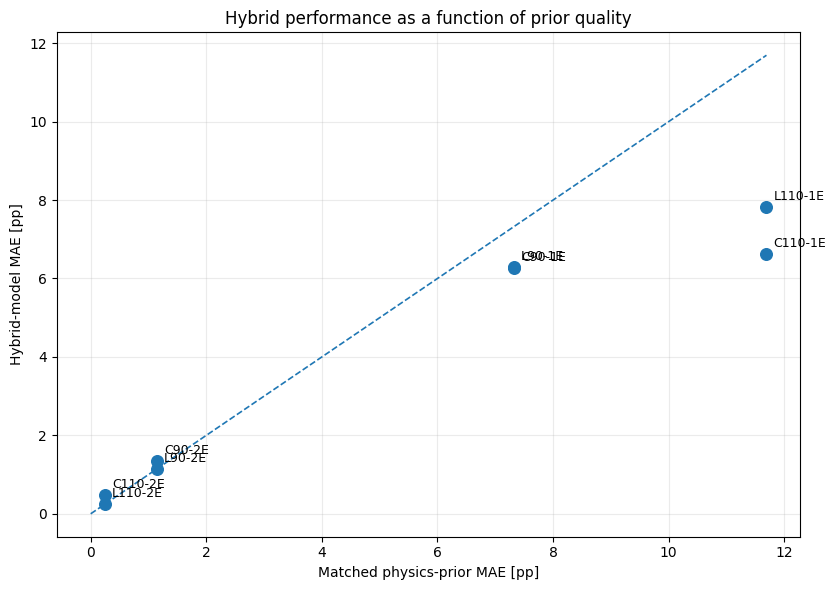

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final/figures/ablation_prior_mae_vs_model_mae.svg


In [33]:
figure_frame = (
    ablation_prior_quality.copy()
)


plt.figure(
    figsize=(8.5, 6.0)
)

plt.scatter(
    figure_frame["prior_mae_pp"],
    figure_frame["model_mae_pp"],
    s=70,
)

maximum_value = float(
    max(
        figure_frame[
            "prior_mae_pp"
        ].max(),
        figure_frame[
            "model_mae_pp"
        ].max(),
    )
)

plt.plot(
    [0, maximum_value],
    [0, maximum_value],
    linestyle="--",
    linewidth=1.2,
)

for _, row in (
    figure_frame.iterrows()
):
    plt.annotate(
        row["experiment_id"],
        (
            row["prior_mae_pp"],
            row["model_mae_pp"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

plt.xlabel(
    "Matched physics-prior MAE [pp]"
)

plt.ylabel(
    "Hybrid-model MAE [pp]"
)

plt.title(
    "Hybrid performance as a function of prior quality"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "ablation_prior_mae_vs_model_mae.svg"
)

plt.savefig(
    figure_path,
    format="svg",
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

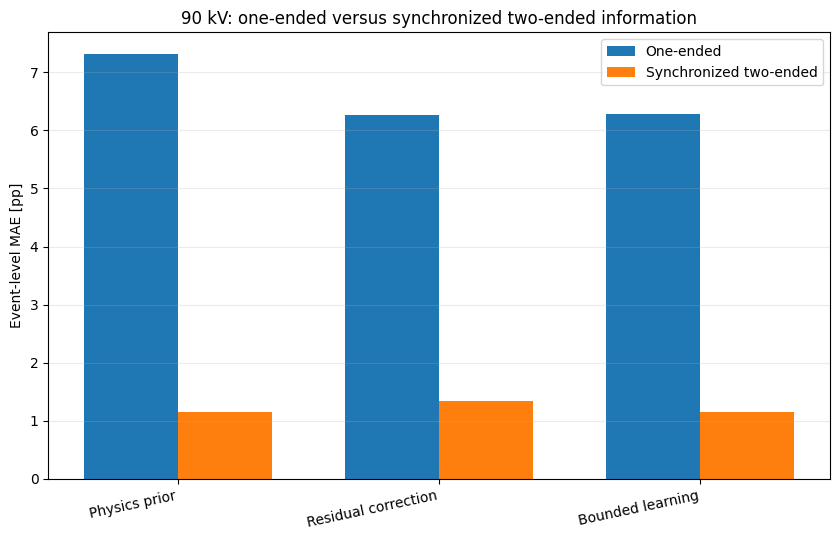

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final/figures/ablation_oneended_vs_twoended_90kv.svg


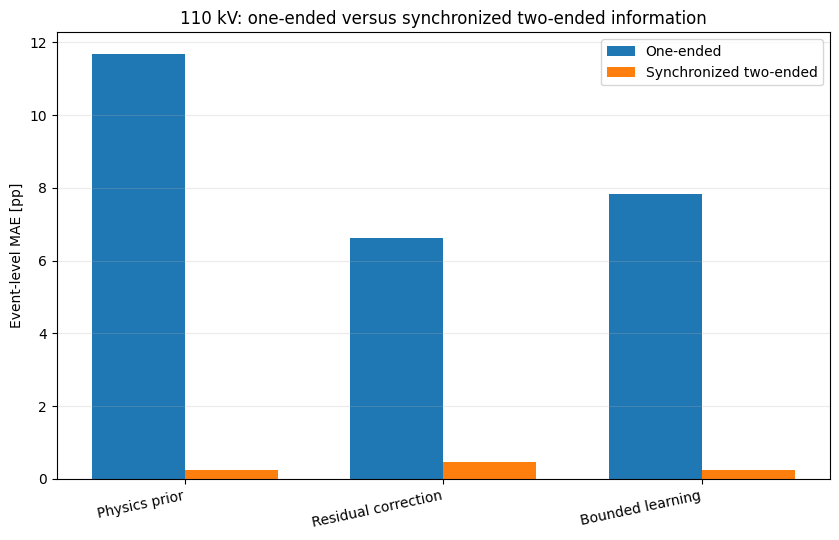

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final/figures/ablation_oneended_vs_twoended_110kv.svg


In [19]:
figure_frame = (
    ablation_oneended_vs_twoended
    .copy()
)


for voltage_kv in [
    90,
    110,
]:
    voltage_frame = (
        figure_frame.loc[
            figure_frame[
                "voltage_kv"
            ] == voltage_kv
        ].copy()
    )

    voltage_frame[
        "model_family_label"
    ] = voltage_frame[
        "model_family"
    ].map(
        {
            "physics_prior": (
                "Physics prior"
            ),
            "correction": (
                "Residual correction"
            ),
            "bounded_learning": (
                "Bounded learning"
            ),
        }
    )

    positions = np.arange(
        len(voltage_frame)
    )

    width = 0.36

    plt.figure(
        figsize=(8.5, 5.5)
    )

    plt.bar(
        positions - width / 2,
        voltage_frame[
            "one_ended_mae_pp"
        ],
        width=width,
        label="One-ended",
    )

    plt.bar(
        positions + width / 2,
        voltage_frame[
            "two_ended_mae_pp"
        ],
        width=width,
        label="Synchronized two-ended",
    )

    plt.xticks(
        positions,
        voltage_frame[
            "model_family_label"
        ],
        rotation=12,
        ha="right",
    )

    plt.ylabel(
        "Event-level MAE [pp]"
    )

    plt.title(
        f"{voltage_kv} kV: one-ended versus "
        "synchronized two-ended information"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.25,
    )

    plt.tight_layout()

    figure_path = (
        FIGURE_DIR
        / (
            "ablation_oneended_vs_twoended_"
            f"{voltage_kv}kv.svg"
        )
    )

    plt.savefig(
        figure_path,
        format="svg",
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", figure_path)

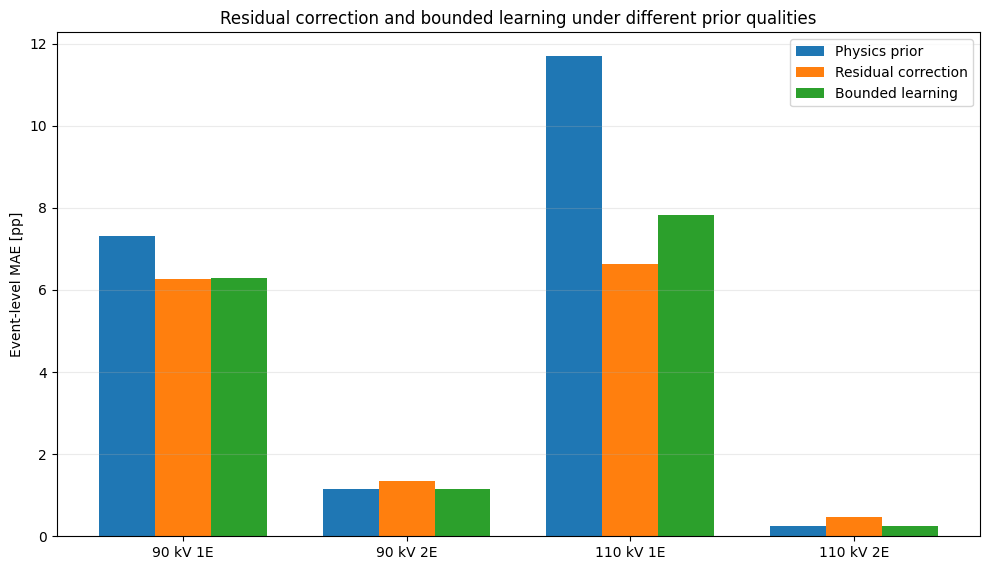

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final/figures/ablation_correction_vs_bounded.svg


In [34]:
comparison_labels = []
prior_values = []
correction_values = []
bounded_values = []


for voltage_kv in [
    90,
    110,
]:
    for prior_view in [
        "1E",
        "2E",
    ]:
        comparison_labels.append(
            f"{voltage_kv} kV {prior_view}"
        )

        correction_row = (
            hybrid_metrics.loc[
                hybrid_metrics[
                    "experiment_id"
                ]
                == f"C{voltage_kv}-{prior_view}"
            ].iloc[0]
        )

        bounded_row = (
            hybrid_metrics.loc[
                hybrid_metrics[
                    "experiment_id"
                ]
                == f"L{voltage_kv}-{prior_view}"
            ].iloc[0]
        )

        prior_values.append(
            correction_row[
                "prior_mae_pp"
            ]
        )

        correction_values.append(
            correction_row[
                "model_mae_pp"
            ]
        )

        bounded_values.append(
            bounded_row[
                "model_mae_pp"
            ]
        )


positions = np.arange(
    len(comparison_labels)
)

width = 0.25


plt.figure(
    figsize=(10.0, 5.8)
)

plt.bar(
    positions - width,
    prior_values,
    width=width,
    label="Physics prior",
)

plt.bar(
    positions,
    correction_values,
    width=width,
    label="Residual correction",
)

plt.bar(
    positions + width,
    bounded_values,
    width=width,
    label="Bounded learning",
)

plt.xticks(
    positions,
    comparison_labels,
)

plt.ylabel(
    "Event-level MAE [pp]"
)

plt.title(
    "Residual correction and bounded learning "
    "under different prior qualities"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "ablation_correction_vs_bounded.svg"
)

plt.savefig(
    figure_path,
    format="svg",
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

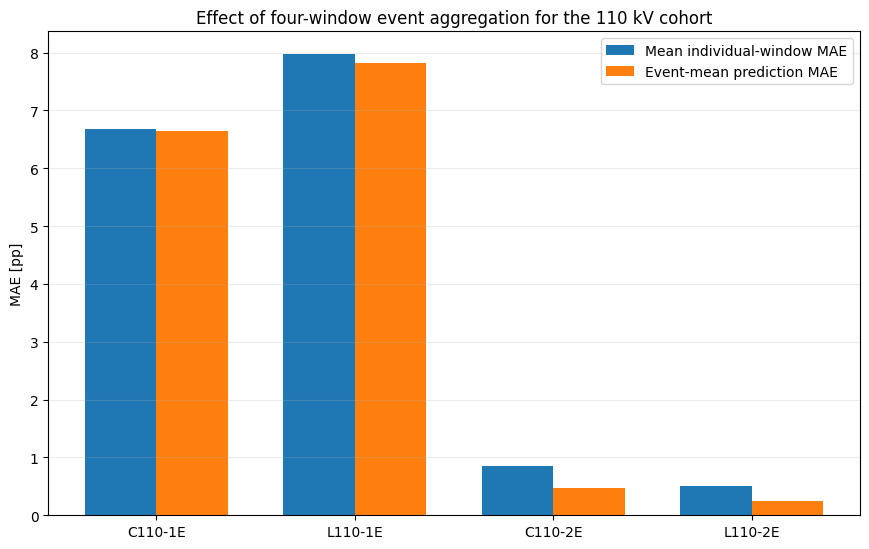

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final/figures/ablation_110kv_window_vs_event_mae.svg


In [21]:
figure_frame = (
    ablation_window_averaging
    .copy()
)


positions = np.arange(
    len(figure_frame)
)

width = 0.36


plt.figure(
    figsize=(8.8, 5.6)
)

plt.bar(
    positions - width / 2,
    figure_frame[
        "mean_individual_window_mae_pp"
    ],
    width=width,
    label="Mean individual-window MAE",
)

plt.bar(
    positions + width / 2,
    figure_frame[
        "event_level_mae_pp"
    ],
    width=width,
    label="Event-mean prediction MAE",
)

plt.xticks(
    positions,
    figure_frame[
        "experiment_id"
    ],
)

plt.ylabel(
    "MAE [pp]"
)

plt.title(
    "Effect of four-window event aggregation "
    "for the 110 kV cohort"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "ablation_110kv_window_vs_event_mae.svg"
)

plt.savefig(
    figure_path,
    format="svg",
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

In [35]:
operator_figure_created = False
operator_figure_path = None


comparable_counts = (
    physics_operator_comparable
    .groupby(
        [
            "voltage_kv",
            "prior_view",
            "event_count",
        ],
        dropna=False,
    )
    .size()
    .sort_values(
        ascending=False
    )
)


if (
    not comparable_counts.empty
    and comparable_counts.iloc[0] >= 3
):
    selected_group = (
        comparable_counts.index[0]
    )

    selected_voltage = (
        selected_group[0]
    )

    selected_prior_view = (
        selected_group[1]
    )

    selected_event_count = (
        selected_group[2]
    )

    operator_figure_frame = (
        physics_operator_comparable.loc[
            (
                physics_operator_comparable[
                    "voltage_kv"
                ] == selected_voltage
            )
            & (
                physics_operator_comparable[
                    "prior_view"
                ] == selected_prior_view
            )
            & (
                physics_operator_comparable[
                    "event_count"
                ] == selected_event_count
            )
        ]
        .sort_values(
            [
                "operator_stage_order",
                "mae_pp",
            ],
            kind="stable",
        )
        .drop_duplicates(
            subset=[
                "operator_stage",
                "operator_name",
            ]
        )
        .copy()
    )

    if len(operator_figure_frame) >= 3:
        positions = np.arange(
            len(operator_figure_frame)
        )

        plt.figure(
            figsize=(10.0, 5.8)
        )

        plt.plot(
            positions,
            operator_figure_frame[
                "mae_pp"
            ],
            marker="o",
        )

        plt.xticks(
            positions,
            operator_figure_frame[
                "operator_name"
            ],
            rotation=30,
            ha="right",
        )

        plt.ylabel(
            "Event-level MAE [pp]"
        )

        plt.title(
            "Physical-operator evolution: "
            f"{selected_voltage} kV "
            f"{selected_prior_view}"
        )

        plt.grid(
            alpha=0.25,
        )

        plt.tight_layout()

        operator_figure_path = (
            FIGURE_DIR
            / (
                "ablation_physics_operator_"
                f"evolution_{selected_voltage}kv_"
                f"{str(selected_prior_view).lower()}.svg"
            )
        )

        plt.savefig(
            operator_figure_path,
            format="svg",
            bbox_inches="tight",
        )

        plt.show()

        operator_figure_created = True

        print(
            "Saved:",
            operator_figure_path,
        )


if not operator_figure_created:
    print(
        "No physical-operator evolution figure "
        "was created because fewer than three "
        "strictly comparable operator stages "
        "were identified within one cohort."
    )

No physical-operator evolution figure was created because fewer than three strictly comparable operator stages were identified within one cohort.


In [23]:
generated_artifacts = [
    {
        "artifact_name": (
            "ablation_prior_quality.csv"
        ),
        "artifact_path": str(
            TABLE_DIR
            / "ablation_prior_quality.csv"
        ),
        "comparison_type": (
            "prior_quality"
        ),
        "source_files": json.dumps(
            [
                str(PAIRED_PRIOR_PATH),
                str(BOOTSTRAP_PATH),
                str(FOLD_SUMMARY_PATH),
                str(UNIFIED_EVENT_PATH),
            ]
        ),
        "directly_comparable": True,
    },
    {
        "artifact_name": (
            "ablation_correction_vs_bounded.csv"
        ),
        "artifact_path": str(
            TABLE_DIR
            / "ablation_correction_vs_bounded.csv"
        ),
        "comparison_type": (
            "correction_vs_bounded"
        ),
        "source_files": json.dumps(
            [
                str(UNIFIED_EVENT_PATH),
                str(EVENT_TAIL_PATH),
                str(FOLD_SUMMARY_PATH),
            ]
        ),
        "directly_comparable": True,
    },
    {
        "artifact_name": (
            "ablation_oneended_vs_twoended.csv"
        ),
        "artifact_path": str(
            TABLE_DIR
            / "ablation_oneended_vs_twoended.csv"
        ),
        "comparison_type": (
            "information_and_prior_quality"
        ),
        "source_files": json.dumps(
            [
                str(UNIFIED_EVENT_PATH),
            ]
        ),
        "directly_comparable": bool(
            (
                ablation_oneended_vs_twoended[
                    "comparability_status"
                ]
                == "DIRECTLY_COMPARABLE"
            ).all()
        ),
    },
    {
        "artifact_name": (
            "ablation_window_averaging.csv"
        ),
        "artifact_path": str(
            TABLE_DIR
            / "ablation_window_averaging.csv"
        ),
        "comparison_type": (
            "window_aggregation"
        ),
        "source_files": json.dumps(
            [
                str(WINDOW_HEADLINE_PATH),
            ]
        ),
        "directly_comparable": True,
    },
    {
        "artifact_name": (
            "ablation_waveform_vs_hybrid.csv"
        ),
        "artifact_path": str(
            TABLE_DIR
            / "ablation_waveform_vs_hybrid.csv"
        ),
        "comparison_type": (
            "waveform_only_vs_physics_guided"
        ),
        "source_files": json.dumps(
            selected_gru[
                "selected_path"
            ]
            .dropna()
            .astype(str)
            .tolist()
            + [
                str(UNIFIED_EVENT_PATH),
            ]
        ),
        "directly_comparable": bool(
            (
                selected_gru["status"]
                == "DIRECTLY_COMPARABLE"
            ).all()
        ),
    },
    {
        "artifact_name": (
            "ablation_physics_operator_inventory.csv"
        ),
        "artifact_path": str(
            TABLE_DIR
            / "ablation_physics_operator_inventory.csv"
        ),
        "comparison_type": (
            "physical_operator_evolution"
        ),
        "source_files": json.dumps(
            sorted(
                physics_operator_inventory[
                    "source_file"
                ]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )
        ),
        "directly_comparable": False,
    },
]


for figure_path in sorted(
    FIGURE_DIR.glob("*.svg")
):
    generated_artifacts.append(
        {
            "artifact_name": (
                figure_path.name
            ),
            "artifact_path": str(
                figure_path
            ),
            "comparison_type": (
                "thesis_figure"
            ),
            "source_files": (
                "See corresponding table "
                "artifact in manifest."
            ),
            "directly_comparable": True,
        }
    )


ablation_manifest = pd.DataFrame(
    generated_artifacts
)


ablation_manifest[
    "creation_timestamp_utc"
] = datetime.now(
    timezone.utc
).isoformat()


try:
    import subprocess

    git_commit = subprocess.check_output(
        [
            "git",
            "-C",
            str(THESIS_DIR),
            "rev-parse",
            "HEAD",
        ],
        text=True,
        stderr=subprocess.DEVNULL,
    ).strip()

except Exception:
    git_commit = None


ablation_manifest[
    "git_commit"
] = git_commit


ablation_manifest.to_csv(
    ABLATION_DIR
    / "ablation_manifest.csv",
    index=False,
)


display(ablation_manifest)

,artifact_name,artifact_path,comparison_type,source_files,directly_comparable,creation_timestamp_utc,git_commit
0,ablation_prior_quality.csv,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,prior_quality,"[""/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LA...",True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
1,ablation_correction_vs_bounded.csv,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,correction_vs_bounded,"[""/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LA...",True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
2,ablation_oneended_vs_twoended.csv,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,information_and_prior_quality,"[""/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LA...",True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
3,ablation_window_averaging.csv,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,window_aggregation,"[""/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LA...",True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
4,ablation_waveform_vs_hybrid.csv,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,waveform_only_vs_physics_guided,"[""/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LA...",False,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
5,ablation_physics_operator_inventory.csv,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,physical_operator_evolution,"[""/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LA...",False,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
6,ablation_110kv_window_vs_event_mae.svg,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,thesis_figure,See corresponding table artifact in manifest.,True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
7,ablation_correction_vs_bounded.svg,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,thesis_figure,See corresponding table artifact in manifest.,True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
8,ablation_oneended_vs_twoended_110kv.svg,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,thesis_figure,See corresponding table artifact in manifest.,True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4
9,ablation_oneended_vs_twoended_90kv.svg,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,thesis_figure,See corresponding table artifact in manifest.,True,2026-07-20T08:49:36.368965+00:00,c2f7f95226cf542349f79b2a5cce59d8c130e2a4


In [37]:
directly_comparable_tables = [
    "ablation_prior_quality",
    "ablation_correction_vs_bounded",
    "ablation_oneended_vs_twoended",
    "ablation_window_averaging",
    "ablation_waveform_vs_hybrid",
]


descriptive_only_tables = []


if not physics_operator_descriptive.empty:
    descriptive_only_tables.append(
        "ablation_physics_operator_descriptive"
    )


missing_essential_comparisons = []


for _, row in selected_gru.iterrows():
    if row["status"] != (
        "DIRECTLY_COMPARABLE"
    ):
        missing_essential_comparisons.append(
            (
                f"{row['gru_id']}: "
                f"{row['status']}"
            )
        )


recommended_new_experiments = []
new_training_runs_launched = 0


completion_summary = {
    "notebook": (
        "06_chapter4_ablation_evidence"
    ),
    "status": (
        "PASS"
        if not missing_essential_comparisons
        else "PASS_WITH_DESCRIPTIVE_GAPS"
    ),
    "existing_final_hybrid_experiments_reused": (
        HYBRID_EXPERIMENT_ORDER
    ),
    "waveform_only_gru_experiments_reused": (
        selected_gru[
            "gru_id"
        ].tolist()
    ),
    "new_training_runs_launched": (
        new_training_runs_launched
    ),
    "directly_comparable_ablation_tables": (
        directly_comparable_tables
    ),
    "descriptive_only_tables": (
        descriptive_only_tables
    ),
    "missing_essential_comparisons": (
        missing_essential_comparisons
    ),
    "recommended_new_experiments": (
        recommended_new_experiments
    ),
    "physics_operator_inventory_rows": int(
        len(physics_operator_inventory)
    ),
    "strictly_comparable_operator_rows": int(
        len(physics_operator_comparable)
    ),
    "descriptive_operator_rows": int(
        len(physics_operator_descriptive)
    ),
    "physical_operator_figure_created": bool(
        operator_figure_created
    ),
    "svg_figures_created": [
        path.name
        for path in sorted(
            FIGURE_DIR.glob("*.svg")
        )
    ],
    "output_directory": str(
        ABLATION_DIR
    ),
    "creation_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
}


completion_path = (
    ABLATION_DIR
    / "06_ablation_completion_summary.json"
)


with completion_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_summary,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("=" * 80)
print("CHAPTER 4 ABLATION EVIDENCE COMPLETE")
print("=" * 80)

print(
    "Existing final hybrid experiments reused:",
    len(HYBRID_EXPERIMENT_ORDER),
)

print(
    "Waveform-only GRU experiments reused:",
    ", ".join(
        selected_gru[
            "gru_id"
        ].tolist()
    ),
)

print(
    "New training runs launched:",
    new_training_runs_launched,
)

print(
    "Directly comparable ablation tables:",
    ", ".join(
        directly_comparable_tables
    ),
)

print(
    "Descriptive-only tables:",
    (
        ", ".join(
            descriptive_only_tables
        )
        if descriptive_only_tables
        else "None"
    ),
)

print(
    "Missing essential comparisons:",
    (
        "; ".join(
            missing_essential_comparisons
        )
        if missing_essential_comparisons
        else "None"
    ),
)

print(
    "Recommended new experiments:",
    "None",
)

print(
    "Physics-operator inventory rows:",
    len(physics_operator_inventory),
)

print(
    "Strictly comparable operator rows:",
    len(physics_operator_comparable),
)

print(
    "Physical-operator evolution figure:",
    (
        "created"
        if operator_figure_created
        else "intentionally omitted"
    ),
)

print(
    "SVG figures created:",
    len(
        list(
            FIGURE_DIR.glob("*.svg")
        )
    ),
)

print(
    "Output directory:",
    ABLATION_DIR,
)

print("=" * 80)

print(
    "\nNo training or Slurm job was launched."
)

CHAPTER 4 ABLATION EVIDENCE COMPLETE
Existing final hybrid experiments reused: 8
Waveform-only GRU experiments reused: G90, G110
New training runs launched: 0
Directly comparable ablation tables: ablation_prior_quality, ablation_correction_vs_bounded, ablation_oneended_vs_twoended, ablation_window_averaging, ablation_waveform_vs_hybrid
Descriptive-only tables: ablation_physics_operator_descriptive
Missing essential comparisons: None
Recommended new experiments: None
Physics-operator inventory rows: 268
Strictly comparable operator rows: 4
Physical-operator evolution figure: intentionally omitted
SVG figures created: 5
Output directory: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/ablation_final

No training or Slurm job was launched.
